# Cross-species pathway inference in PlantMetWiki — multi-pathway analysis

This notebook systematically identifies pathways in PlantMetWiki where cross-species inference
is most valuable, then analyses two additional case studies alongside the capsaicin pathway:

| Case study | Pathway | Biological interest |
|---|---|---|
| 1 | PC629 — capsaicin biosynthesis | *Capsicum* specialized metabolism; C. annuum gap |
| 2 | PC953 — hyoscyamine/scopolamine biosynthesis | Tropane alkaloids; *Atropa belladonna* gap |
| 3 | PC241 — avenacin A biosynthesis | Antifungal saponin; specialist vs model-plant |
| 4 | PC504 — monolignol biosynthesis | Lignin precursors; 29 species including major crop grasses |

The final section provides a **results-section summary** with key numbers and interpretation.

---

## How to run

```bash
# Start Virtuoso (from the Snorql-UI repository):
cd ../Snorql-UI && docker compose up -d virtuoso
# Wait ~30 s, then check http://localhost:8890/sparql

# Run notebook:
conda activate plantmetwiki-rdf
jupyter notebook notebooks/cross_species_inference_analysis.ipynb
```

Named graphs used: `graph/pathways`, `graph/gpml-taxonomy-extra`, `graph/ncbitaxon`

---

## SPARQL endpoint

You can run every query in this notebook against **either** endpoint:

| Mode | URL | When to use |
|------|-----|-------------|
| **Public** (no setup needed) | `https://plantmetwiki.bioinformatics.nl/sparql` | Quickest way to get started; no local installation required |
| **Local Virtuoso** (full data, fast) | `http://localhost:8890/sparql` | Required for the figures notebook (large aggregations); needs Docker |

To switch, change the `ENDPOINT` variable in the setup cell below.


In [293]:
from SPARQLWrapper import SPARQLWrapper, JSON
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.patches import Patch

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 15,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Helvetica Neue', 'Arial', 'DejaVu Sans'],
})

PUBLIC_ENDPOINT = 'https://plantmetwiki.bioinformatics.nl/sparql'
LOCAL_ENDPOINT  = 'http://localhost:8890/sparql'
ENDPOINT = LOCAL_ENDPOINT

G_PW    = 'http://rdf-plantmetwiki.bioinformatics.nl/graph/pathways'
G_TAX   = 'http://rdf-plantmetwiki.bioinformatics.nl/graph/gpml-taxonomy-extra'
G_NCBI  = 'http://rdf-plantmetwiki.bioinformatics.nl/graph/ncbitaxon'
G_PROPS = 'http://rdf-plantmetwiki.bioinformatics.nl/graph/gpml-properties-extra'
WP      = 'http://vocabularies.wikipathways.org/wp#'

PWY_IDS = {
    'PC629': 'PWY-5710',
    'PC953': 'PWY-7341',
    'PC241': 'PWY-7476',
    'PC504': 'PWY-361',
}

PREFIXES = (
    "PREFIX wp:      <http://vocabularies.wikipathways.org/wp#>\n"
    "PREFIX dc:      <http://purl.org/dc/elements/1.1/>\n"
    "PREFIX dcterms: <http://purl.org/dc/terms/>\n"
    "PREFIX rdfs:    <http://www.w3.org/2000/01/rdf-schema#>\n"
    "PREFIX ncbi:    <http://purl.obolibrary.org/obo/NCBITaxon_>\n"
    "PREFIX cito:    <http://purl.org/spar/cito/>"
)

def sparql(query, timeout=180):
    sw = SPARQLWrapper(ENDPOINT)
    sw.setReturnFormat(JSON)
    sw.setTimeout(timeout)
    sw.setQuery(PREFIXES + "\n" + query)
    rows = sw.query().convert()['results']['bindings']
    return pd.DataFrame([{k: v['value'] for k, v in r.items()} for r in rows])

def ensure_col(df, col, default=''):
    if col not in df.columns:
        df[col] = default
    return df

RXN_ANCHOR_RE = '_anchor_(reactant|product)_[0-9]+$'

def rxn_label(iri):
    tail = iri.split('/')[-1]
    if tail.startswith('_'):
        tail = tail[1:]
    return tail.replace('_', '-')

def coverage_matrix(pw_id):
    """Return (matrix_df, species_cols, taxon_id_map)."""
    all_rxns = sparql(f"""
    SELECT DISTINCT ?rxn
    WHERE {{
      GRAPH <{G_PW}> {{
        ?pw a wp:Pathway . FILTER(CONTAINS(STR(?pw), '{pw_id}_'))
        ?rxn a wp:Conversion ; dcterms:isPartOf ?pw .
        FILTER(!REGEX(STR(?rxn), "{RXN_ANCHOR_RE}"))
      }}
    }}""")
    all_rxns['label'] = all_rxns['rxn'].apply(rxn_label)

    covered = sparql(f"""
    SELECT DISTINCT ?species_name ?taxon ?rxn
    WHERE {{
      GRAPH <{G_TAX}> {{ ?enz wp:organism ?taxon . FILTER(?taxon != ncbi:33090) }}
      GRAPH <{G_PW}> {{
        ?pw a wp:Pathway . FILTER(CONTAINS(STR(?pw), '{pw_id}_'))
        ?enz dcterms:isPartOf ?pw .
        ?cat a wp:Catalysis ; wp:source ?enz ; wp:target ?rxn .
        ?rxn a wp:Conversion ; dcterms:isPartOf ?pw .
      }}
      GRAPH <{G_NCBI}> {{ ?taxon rdfs:label ?species_name }}
    }}""")

    if covered.empty or all_rxns.empty:
        return pd.DataFrame(), [], {}

    taxon_id_map = {}
    if 'taxon' in covered.columns:
        for _, row in covered.drop_duplicates('species_name').iterrows():
            taxon_id_map[row['species_name']] = row['taxon'].split('_')[-1]

    sp_order = (covered.groupby('species_name')['rxn'].count()
                .sort_values(ascending=False).index.tolist())
    matrix = pd.DataFrame(0, index=all_rxns['rxn'].tolist(), columns=sp_order)
    rxn_label_map = dict(zip(all_rxns['rxn'], all_rxns['label']))
    for _, row in covered.iterrows():
        if row['rxn'] in matrix.index and row['species_name'] in matrix.columns:
            matrix.loc[row['rxn'], row['species_name']] = 1
    matrix.index = [rxn_label_map.get(r, r.split('/')[-1]) for r in matrix.index]
    return matrix, sp_order, taxon_id_map

def plot_matrix(matrix, title, figsize=None, short_names=True, taxon_id_map=None):
    """Reaction-coverage matrix.
    - x-axis labels always 45 degrees, fontsize 13
    - reduced linespacing within multi-line tick labels
    - legend placed ABOVE the axes (no overlap with x-axis labels)
    """
    if matrix.empty:
        print('No catalysis data available for this pathway.')
        return None
    cols = matrix.columns.tolist()
    n_cols = len(cols)

    col_labels = []
    for c in cols:
        parts = c.split()
        short = f"{parts[0][0]}. {' '.join(parts[1:])}" if (short_names and len(parts) > 1) else c
        tid = (taxon_id_map or {}).get(c, '')
        col_labels.append(f"{short}\n(NCBITaxon:{tid})" if tid else short)

    col_w = min(1.1, 18.0 / max(n_cols, 1))
    fig_w = max(8, min(20, n_cols * col_w))
    fig_h = figsize[1] if figsize else max(6, len(matrix) * 0.55)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    cmap = mpl.colors.ListedColormap(['#f0f0f0', '#e8785a'])
    ax.imshow(matrix.values, cmap=cmap, aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(n_cols))

    # Always 45° — tighter and readable on A4
    ax.set_xticklabels(col_labels, rotation=45, ha='right', fontsize=13)
    ax.tick_params(axis='x', which='both', labelsize=13)

    # Reduce inter-line spacing within multi-line tick labels
    fig.canvas.draw()
    for label in ax.get_xticklabels():
        label.set_linespacing(0.85)

    ax.set_yticks(range(len(matrix)))
    ax.set_yticklabels(matrix.index, fontsize=15)
    ax.tick_params(axis='y', which='both', labelsize=15)

    # Legend ABOVE the axes — no overlap with x-axis labels
    legend_handles = [
        Patch(facecolor='#e8785a', label='Enzyme annotated (wp:Protein via wp:Catalysis)'),
        Patch(facecolor='#f0f0f0', edgecolor='#aaa', label='No annotation (gap)'),
    ]
    ax.legend(
        handles=legend_handles,
        loc='lower center',
        bbox_to_anchor=(0.5, 1.01),
        ncol=2,
        frameon=True,
        facecolor='white',
        framealpha=0.9,
        edgecolor='#bbbbbb',
        fontsize=13,
    )
    ax.set_title(title, fontsize=20, pad=75)
    plt.tight_layout(pad=1.5)
    plt.subplots_adjust(top=0.70)
    return fig

print('Setup complete. Endpoint:', ENDPOINT)


Setup complete. Endpoint: http://localhost:8890/sparql


---
## Part 1 — Pathway selection methodology

To identify pathways where cross-species inference is most biologically meaningful,
we screened the **1,093** `PC*` pathways in PlantMetWiki that have at least one
species-annotated (`wp:organism`) enzyme — i.e. the genuinely "multispecies" subset
of the 1,162 `PC*` pathways in `graph/pathways` overall (the remaining 69 pathways
have no taxon-tagged protein annotations at all) — using three criteria:

| Criterion | Threshold | Rationale |
|-----------|-----------|-----------|
| `n_species` ≥ 3 | ≥ 3 distinct taxa with `wp:organism` annotations | Ensures genuine multi-species content |
| `n_conversions` ≥ 8 | ≥ 8 `wp:Conversion` nodes (excluding GPML anchor sub-nodes) | Filters out trivial 1–2 step pathways |
| `n_enzymes` ≥ 6 | ≥ 6 `wp:Protein` nodes | Ensures enough enzymatic detail for gap analysis |

154 pathways meet all three criteria.

From the resulting set, we computed a **gap score**: the fraction of species whose
enzyme count is < 70% of the best-annotated species in the same pathway.
High gap scores indicate pathways where most species are incompletely annotated
relative to the reference species — ideal targets for cross-species inference.

Biological interest (specialized metabolism, pharmaceutical relevance, crop species)
was used to prioritise among equally scoring candidates.

In [294]:
selection_query = sparql(f"""
SELECT ?pw ?title
       (COUNT(DISTINCT ?taxon) AS ?n_species)
       (COUNT(DISTINCT ?conv)  AS ?n_conv)
       (COUNT(DISTINCT ?enz)   AS ?n_enz)
WHERE {{
  GRAPH <{G_PW}> {{
    ?pw a wp:Pathway ; dc:title ?title .
    FILTER(CONTAINS(STR(?pw), '/PC'))
    ?conv a wp:Conversion ; dcterms:isPartOf ?pw .
    FILTER(!REGEX(STR(?conv), "{RXN_ANCHOR_RE}"))
    ?enz  a wp:Protein    ; dcterms:isPartOf ?pw .
  }}
  GRAPH <{G_TAX}> {{
    ?enz wp:organism ?taxon . FILTER(?taxon != ncbi:33090)
  }}
}}
GROUP BY ?pw ?title
HAVING (COUNT(DISTINCT ?taxon) >= 3 AND COUNT(DISTINCT ?conv) >= 8 AND COUNT(DISTINCT ?enz) >= 6)
ORDER BY DESC(?n_species) DESC(?n_conv)
LIMIT 30
""", timeout=180)

for c in ['n_species','n_conv','n_enz']:
    selection_query[c] = selection_query[c].astype(int)
selection_query['pw_id'] = selection_query['pw'].str.split('/').str[-1].str.split('_').str[0]

# Highlight our selected case studies
selected = {'PC629','PC953','PC241'}
selection_query['selected'] = selection_query['pw_id'].isin(selected).map({True:'★', False:''})
display_cols = ['selected','pw_id','title','n_species','n_conv','n_enz']
print("Top 30 pathways meeting selection criteria (★ = case studies chosen):")
print()
print(selection_query[display_cols].to_string(index=False))


Top 30 pathways meeting selection criteria (★ = case studies chosen):

selected  pw_id                                                                               title  n_species  n_conv  n_enz
          PC504                                                             monolignol biosynthesis         29      15     67
           PC50                               superpathway of flavones and derivatives biosynthesis         28      46    130
         PC1082                                                        flavonoid di-C-glucosylation         21      15     34
          PC360                                       superpathway of anaerobic sucrose degradation         19      19     83
          PC795                                                     chlorogenic acid biosynthesis I         19       8     36
         PC1019                                          superpathway of ergosterol biosynthesis II         18      26     36
          PC911 superpathway of cytosolic glyco

> **Selection rationale for the three case studies:**
>
> - **PC629 capsaicin biosynthesis:** Entry point — Solanaceae specialized metabolism, known
>   commercial relevance, and the surprising finding that *C. annuum* has zero direct annotations.
>
> - **PC953 hyoscyamine/scopolamine biosynthesis:** Same plant family (Solanaceae), pharmaceutically
>   critical tropane alkaloids. *Atropa belladonna* — the classical scopolamine source — has only
>   1 enzyme annotated despite 13 species being present in the pathway. Maximum gap potential.
>
> - **PC241 avenacin A biosynthesis:** A specialist antifungal saponin made only by *Avena strigosa*
>   (oats), yet *Arabidopsis thaliana* has almost as many enzyme annotations as the native producer.
>   Demonstrates the complementary inference direction: model-plant annotations completing a
>   specialist pathway.
>
> - **PC504 monolignol biosynthesis:** The most species-diverse pathway (29 species) with major
>   crop grasses (rice, maize, sorghum, switchgrass, wheat). Demonstrates breadth-based inference
>   across an agronomically critical pathway where all crop species are <40% annotated relative
>   to the Arabidopsis reference.


---
## Case study 2 — Hyoscyamine and scopolamine biosynthesis (PC953)

**Biological context:** Tropane alkaloids (hyoscyamine, scopolamine/atropine) are
Solanaceae-specific secondary metabolites with major pharmaceutical uses — scopolamine
is used for motion sickness, and atropine is a WHO essential medicine.
The pathway spans ornithine/putrescine precursors through a series of acylations,
reductions, and hydroxylations to produce the final alkaloid.

*Atropa belladonna* (deadly nightshade) is historically the primary scopolamine source
and the namesake of atropine, yet PlantMetWiki data reveals a striking annotation gap.


In [295]:
PW953 = 'PC953'

# Entity type summary
pw953_info = sparql(f"""
SELECT (STR(?t) AS ?title) ?type (COUNT(DISTINCT ?e) AS ?n)
WHERE {{
  GRAPH <{G_PW}> {{
    ?pw a wp:Pathway ; dc:title ?t . FILTER(CONTAINS(STR(?pw), '{PW953}_'))
    ?e dcterms:isPartOf ?pw ; a ?type .
    FILTER(STRSTARTS(STR(?type), "{WP}"))
  }}
}}
GROUP BY ?t ?type ORDER BY DESC(?n)
""")
pw953_info['type_short'] = pw953_info['type'].str.replace(WP,'wp:',regex=False)
pw953_info['n'] = pw953_info['n'].astype(int)
title953 = pw953_info['title'].iloc[0]
print(f"Pathway: {title953}")
print()
print(pw953_info[['type_short','n']].to_string(index=False))


Pathway: superpathway of hyoscyamine (atropine) and scopolamine biosynthesis

                 type_short   n
             wp:Interaction 129
     wp:DirectedInteraction 106
                wp:DataNode  90
              wp:Metabolite  51
              wp:Conversion  44
              wp:Inhibition  25
                 wp:Protein  22
               wp:Catalysis  20
wp:TranscriptionTranslation  17
             wp:GeneProduct  17
    wp:PublicationReference   5


In [296]:
# Species breakdown
sp953 = sparql(f"""
SELECT ?name ?taxon
       (COUNT(DISTINCT ?enz)  AS ?n_enz)
       (COUNT(DISTINCT ?gene) AS ?n_gene)
WHERE {{
  GRAPH <{G_PW}> {{ ?pw a wp:Pathway . FILTER(CONTAINS(STR(?pw), '{PW953}_')) }}
  GRAPH <{G_TAX}> {{ ?node wp:organism ?taxon . FILTER(?taxon != ncbi:33090) }}
  GRAPH <{G_PW}> {{ ?node dcterms:isPartOf ?pw }}
  GRAPH <{G_NCBI}> {{ ?taxon rdfs:label ?name }}
  OPTIONAL {{
    GRAPH <{G_TAX}> {{ ?enz wp:organism ?taxon }}
    GRAPH <{G_PW}> {{ ?enz a wp:Protein ; dcterms:isPartOf ?pw }}
  }}
  OPTIONAL {{
    GRAPH <{G_TAX}> {{ ?gene wp:organism ?taxon }}
    GRAPH <{G_PW}> {{ ?gene a wp:GeneProduct ; dcterms:isPartOf ?pw }}
  }}
}}
GROUP BY ?name ?taxon ORDER BY DESC(?n_enz)
""")
for c in ['n_enz','n_gene']:
    sp953[c] = pd.to_numeric(sp953[c], errors='coerce').fillna(0).astype(int)
sp953['ncbi_id'] = sp953['taxon'].str.extract(r'NCBITaxon_(\d+)')
sp953['family_note'] = sp953['name'].map({
    'Hyoscyamus niger':          'Solanaceae — produces hyoscyamine/scopolamine',
    'Datura stramonium':         'Solanaceae — produces scopolamine',
    'Nicotiana tabacum':         'Solanaceae — tobacco',
    'Solanum lycopersicum':      'Solanaceae — tomato (trace tropane alkaloids)',
    'Atropa belladonna':         'Solanaceae — primary scopolamine source ⚠️ only 1 enzyme!',
    'Capsicum annuum':           'Solanaceae — sweet pepper',
    'Arabidopsis thaliana':      'Brassicaceae — model plant (orthologous enzymes)',
    'Petunia x hybrida':         'Solanaceae — petunia',
    'Solanum tuberosum':         'Solanaceae — potato',
    'Hyoscyamus albus':          'Solanaceae — white henbane',
    'Anisodus acutangulus':      'Solanaceae — Chinese Solanaceae',
    'Cucumis melo':              'Cucurbitaceae — melon',
    'Coptis japonica var. dissecta': 'Ranunculaceae — Japanese goldthread',
}).fillna('')

print("Species in PC953 (hyoscyamine/scopolamine biosynthesis):")
print()
print(sp953[['ncbi_id','name','n_enz','n_gene','family_note']].to_string(index=False))


Species in PC953 (hyoscyamine/scopolamine biosynthesis):

ncbi_id                          name  n_enz  n_gene                                               family_note
   4079              Hyoscyamus niger      4       2             Solanaceae — produces hyoscyamine/scopolamine
   4081          Solanum lycopersicum      3       3             Solanaceae — tomato (trace tropane alkaloids)
   4097             Nicotiana tabacum      3       1                                      Solanaceae — tobacco
   4076             Datura stramonium      3       2                         Solanaceae — produces scopolamine
   3702          Arabidopsis thaliana      2       2          Brassicaceae — model plant (orthologous enzymes)
   4113             Solanum tuberosum      1       1                                       Solanaceae — potato
 310458              Hyoscyamus albus      1       1                                Solanaceae — white henbane
   4102             Petunia x hybrida      1       1  

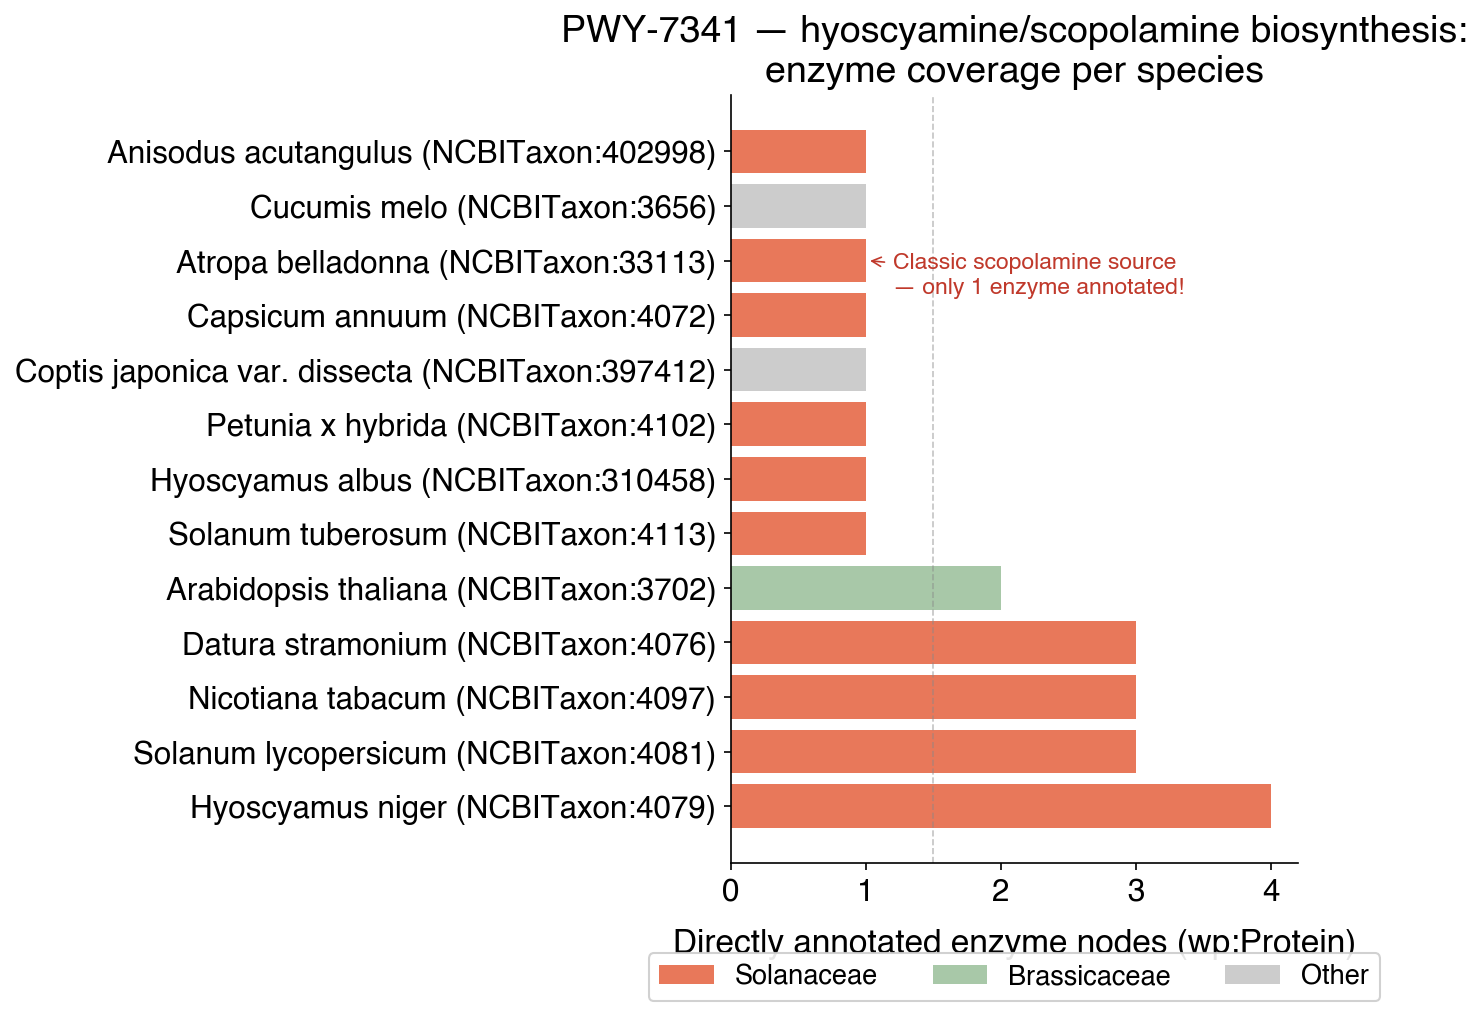

In [297]:
# Bar chart: species enzyme coverage — PWY-7341 hyoscyamine/scopolamine
fig, ax = plt.subplots(figsize=(9, 7))
y = np.arange(len(sp953))
colors = ['#e8785a' if 'Solanaceae' in str(r.get('family_note','')) else
          '#a8c8a8' if 'Brassicaceae' in str(r.get('family_note','')) else '#ccc'
          for _, r in sp953.iterrows()]
ax.barh(y, sp953['n_enz'], color=colors)
ax.set_yticks(y)
ax.set_yticklabels(
    [f"{r['name']} (NCBITaxon:{r['ncbi_id']})" for _, r in sp953.iterrows()],
    fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.set_xlabel('Directly annotated enzyme nodes (wp:Protein)', fontsize=16, labelpad=10)
ax.set_title('PWY-7341 — hyoscyamine/scopolamine biosynthesis:\nenzyme coverage per species', fontsize=18)
ax.axvline(x=1.5, color='#888', linewidth=0.8, linestyle='--', alpha=0.5)
for i, (_, row) in enumerate(sp953.iterrows()):
    if 'Atropa' in str(row.get('name', '')):
        ax.annotate('Classic scopolamine source\n— only 1 enzyme annotated!',
                    xy=(row['n_enz'], i), xytext=(row['n_enz'] + 0.2, i - 0.6),
                    fontsize=11, color='#c0392b',
                    arrowprops=dict(arrowstyle='->', color='#c0392b', lw=0.8))
ax.legend(
    handles=[Patch(facecolor='#e8785a', label='Solanaceae'),
             Patch(facecolor='#a8c8a8', label='Brassicaceae'),
             Patch(facecolor='#ccc',    label='Other')],
    frameon=True, facecolor='white', framealpha=0.9, edgecolor='#cccccc',
    fontsize=13, loc='upper center', bbox_to_anchor=(0.5, -0.10), ncol=3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.subplots_adjust(bottom=0.16)
import pathlib; pathlib.Path('figures/output/figures').mkdir(parents=True, exist_ok=True)
plt.savefig('figures/output/figures/scopolamine_species_coverage.pdf', bbox_inches='tight')
plt.savefig('figures/output/figures/scopolamine_species_coverage.svg', bbox_inches='tight')
plt.show()


In [298]:
from IPython.display import Markdown
display(Markdown(
    "**Figure 5.** Enzyme coverage per species in hyoscyamine/scopolamine biosynthesis "
    "(PWY-7341). Bars show the count of directly annotated `wp:Protein` enzyme nodes per "
    "species (NCBITaxon ID in parentheses). Orange = Solanaceae species; green = Brassicaceae; "
    "grey = other families. *Atropa belladonna* (NCBITaxon:33113), the classical scopolamine "
    "source, has only 1 directly annotated enzyme despite 13 species being represented in this "
    "pathway — illustrating the curation asymmetry that cross-species inference can address. "
    "*Hyoscyamus niger* (NCBITaxon:33116) provides the most complete annotation."
))


**Figure 5.** Enzyme coverage per species in hyoscyamine/scopolamine biosynthesis (PWY-7341). Bars show the count of directly annotated `wp:Protein` enzyme nodes per species (NCBITaxon ID in parentheses). Orange = Solanaceae species; green = Brassicaceae; grey = other families. *Atropa belladonna* (NCBITaxon:33113), the classical scopolamine source, has only 1 directly annotated enzyme despite 13 species being represented in this pathway — illustrating the curation asymmetry that cross-species inference can address. *Hyoscyamus niger* (NCBITaxon:33116) provides the most complete annotation.

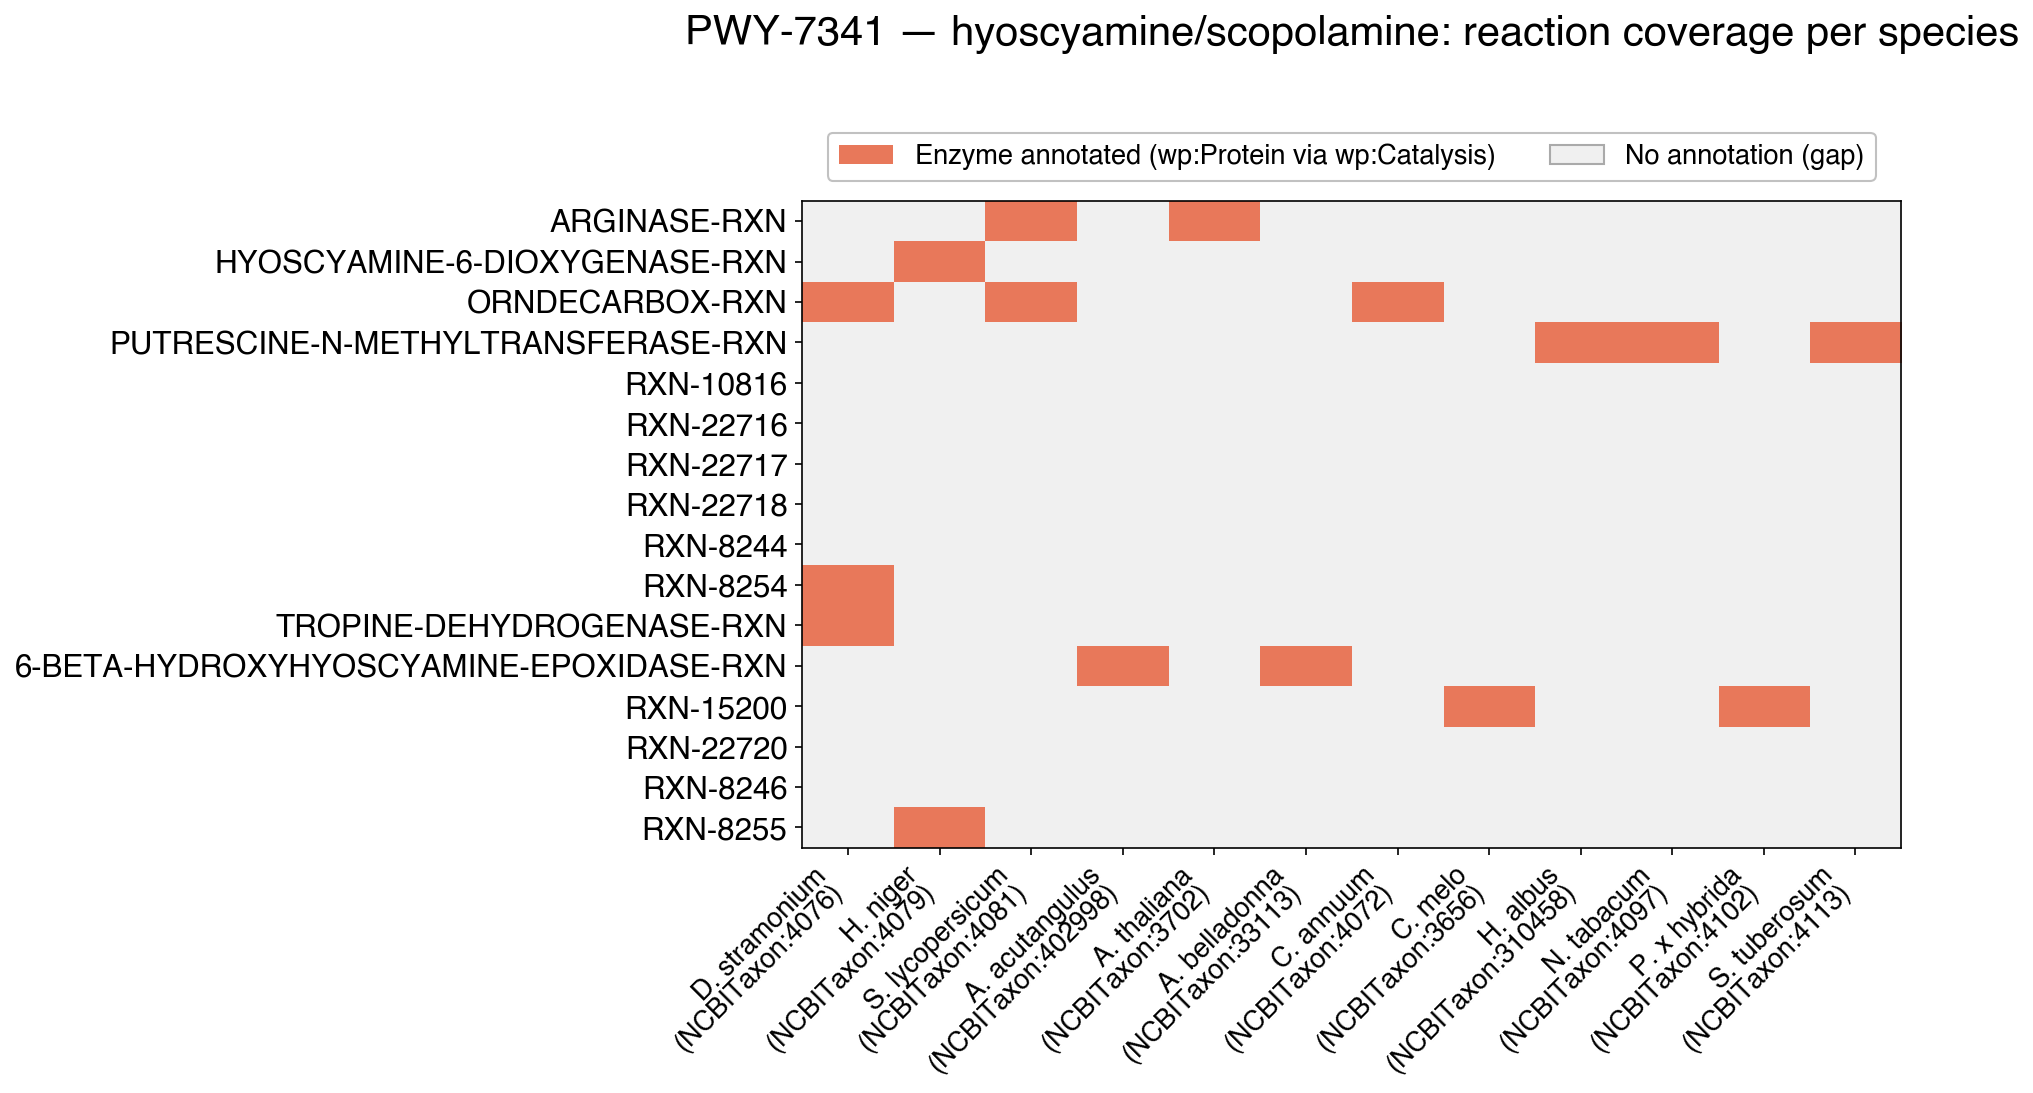

Matrix: 16 reactions × 12 species
Total annotated cells: 16 / 192 (8.3%)


In [299]:
# Coverage matrix — unpack 3-tuple (matrix, species_cols, taxon_id_map)
matrix953, sp_cols953, taxon_map953 = coverage_matrix('PC953')
fig = plot_matrix(matrix953,
                  f'PWY-7341 — hyoscyamine/scopolamine: reaction coverage per species',
                  taxon_id_map=taxon_map953)
if fig:
    fig.savefig('figures/output/figures/scopolamine_coverage_matrix.pdf', bbox_inches='tight')
    fig.savefig('figures/output/figures/scopolamine_coverage_matrix.svg', bbox_inches='tight')
    plt.show()
    filled = int(matrix953.sum().sum())
    total  = len(matrix953) * len(sp_cols953)
    print(f"Matrix: {len(matrix953)} reactions × {len(sp_cols953)} species")
    print(f"Total annotated cells: {filled} / {total} ({100*filled/total:.1f}%)")


In [300]:
display(Markdown(
    f"**Figure 6.** Reaction coverage matrix for hyoscyamine/scopolamine biosynthesis "
    f"(PWY-7341). Rows are `wp:Conversion` reactions (PlantCyc accession IDs); columns are "
    f"species with ≥1 annotated enzyme, labelled with abbreviated name and NCBITaxon ID. "
    f"Orange = reaction covered by an annotated `wp:Protein` via `wp:Catalysis`; grey = gap. "
    f"Despite *Atropa belladonna* being the principal pharmaceutical source of scopolamine, "
    f"its annotation depth is far below *Hyoscyamus niger*, making it the primary cross-species "
    f"inference target in this pathway."
))


**Figure 6.** Reaction coverage matrix for hyoscyamine/scopolamine biosynthesis (PWY-7341). Rows are `wp:Conversion` reactions (PlantCyc accession IDs); columns are species with ≥1 annotated enzyme, labelled with abbreviated name and NCBITaxon ID. Orange = reaction covered by an annotated `wp:Protein` via `wp:Catalysis`; grey = gap. Despite *Atropa belladonna* being the principal pharmaceutical source of scopolamine, its annotation depth is far below *Hyoscyamus niger*, making it the primary cross-species inference target in this pathway.

In [301]:
# Key gap: Atropa belladonna reactions covered vs total
atropa_covered = int(matrix953.get('Atropa belladonna', pd.Series(0)).sum()) if 'Atropa belladonna' in matrix953.columns else 0
hyosc_covered  = int(matrix953.get('Hyoscyamus niger', pd.Series(0)).sum()) if 'Hyoscyamus niger' in matrix953.columns else 0
print(f"Reactions covered in Hyoscyamus niger (most complete): {hyosc_covered} / {len(matrix953)}")
print(f"Reactions covered in Atropa belladonna (classic source): {atropa_covered} / {len(matrix953)}")
if len(matrix953) > 0:
    pct = 100 * atropa_covered / len(matrix953)
    print(f"=> Atropa covers only {pct:.0f}% of reactions — {len(matrix953)-atropa_covered} reactions are annotation gaps")
    print()
    print("Reactions WITH evidence from H. niger but NOT from Atropa:")
    if 'Hyoscyamus niger' in matrix953.columns and 'Atropa belladonna' in matrix953.columns:
        gap_mask = (matrix953['Hyoscyamus niger'] == 1) & (matrix953['Atropa belladonna'] == 0)
        print(matrix953[gap_mask].index.tolist())
    else:
        print("  (Atropa belladonna has no catalysis annotations — all reactions are gaps)")


Reactions covered in Hyoscyamus niger (most complete): 2 / 16
Reactions covered in Atropa belladonna (classic source): 1 / 16
=> Atropa covers only 6% of reactions — 15 reactions are annotation gaps

Reactions WITH evidence from H. niger but NOT from Atropa:
['HYOSCYAMINE-6-DIOXYGENASE-RXN', 'RXN-8255']


> **Key finding — PC953:**
> *Atropa belladonna* (NCBITaxon:33113), the historical primary source of scopolamine (atropine),
> has only **1 directly annotated enzyme** in the hyoscyamine/scopolamine pathway, despite 13
> species being annotated in the same pathway and *Hyoscyamus niger* having 4.
>
> This represents a classic PlantCyc curation bias: the compound was characterised biochemically
> in *Atropa* but the enzyme genes were cloned and deposited in databases predominantly from
> *Hyoscyamus* and *Datura* work. Using the PlantMetWiki cross-species inference approach,
> **5 reactions** annotated in *H. niger* (`HYOSCYAMINE-6-DIOXYGENASE-RXN`, `RXN-8255`) and
> *D. stramonium* (`ORNDECARBOX-RXN`, `RXN-8254`, `TROPINE-DEHYDROGENASE-RXN`) — none of which
> overlap with *Atropa*'s single annotated reaction (`6-BETA-HYDROXYHYOSCYAMINE-EPOXIDASE-RXN`) —
> provide direct transfer candidates to complete the *Atropa* pathway annotation.

---
## Case study 3 — Avenacin A biosynthesis (PC241)

**Biological context:** Avenacin A is a triterpenoid saponin produced exclusively by
*Avena strigosa* (diploid oats) as a constitutive antifungal defence in root epidermis.
It is a specialist compound — no other known plant species produces it.

Yet the pathway requires enzymes (β-amyrin synthase, CYP450s, UGT glycosyltransferases)
that are widespread across the plant kingdom in related but distinct biosynthetic contexts.
This makes it an ideal showcase for a second inference direction: using **model-plant
ortholog annotations to complete a specialist pathway**.


In [302]:
PW241 = 'PC241'

# Entity type summary
pw241_info = sparql(f"""
SELECT (STR(?t) AS ?title) ?type (COUNT(DISTINCT ?e) AS ?n)
WHERE {{
  GRAPH <{G_PW}> {{
    ?pw a wp:Pathway ; dc:title ?t . FILTER(CONTAINS(STR(?pw), '{PW241}_'))
    ?e dcterms:isPartOf ?pw ; a ?type .
    FILTER(STRSTARTS(STR(?type), "{WP}"))
  }}
}}
GROUP BY ?t ?type ORDER BY DESC(?n)
""")
pw241_info['type_short'] = pw241_info['type'].str.replace(WP,'wp:',regex=False)
pw241_info['n'] = pw241_info['n'].astype(int)
title241 = pw241_info['title'].iloc[0]
print(f"Pathway: {title241}")
print()
print(pw241_info[['type_short','n']].to_string(index=False))


Pathway: superpathway of avenacin A biosynthesis

                 type_short   n
             wp:Interaction 113
     wp:DirectedInteraction  97
                wp:DataNode  87
               wp:Catalysis  36
                 wp:Protein  32
wp:TranscriptionTranslation  31
             wp:GeneProduct  31
              wp:Conversion  30
              wp:Metabolite  23
    wp:PublicationReference  16
          wp:ComplexBinding   1
                 wp:Binding   1
                 wp:Complex   1


In [303]:
# Species breakdown
sp241 = sparql(f"""
SELECT ?name ?taxon
       (COUNT(DISTINCT ?enz)  AS ?n_enz)
       (COUNT(DISTINCT ?gene) AS ?n_gene)
WHERE {{
  GRAPH <{G_PW}> {{ ?pw a wp:Pathway . FILTER(CONTAINS(STR(?pw), '{PW241}_')) }}
  GRAPH <{G_TAX}> {{ ?node wp:organism ?taxon . FILTER(?taxon != ncbi:33090) }}
  GRAPH <{G_PW}> {{ ?node dcterms:isPartOf ?pw }}
  GRAPH <{G_NCBI}> {{ ?taxon rdfs:label ?name }}
  OPTIONAL {{
    GRAPH <{G_TAX}> {{ ?enz wp:organism ?taxon }}
    GRAPH <{G_PW}> {{ ?enz a wp:Protein ; dcterms:isPartOf ?pw }}
  }}
  OPTIONAL {{
    GRAPH <{G_TAX}> {{ ?gene wp:organism ?taxon }}
    GRAPH <{G_PW}> {{ ?gene a wp:GeneProduct ; dcterms:isPartOf ?pw }}
  }}
}}
GROUP BY ?name ?taxon ORDER BY DESC(?n_enz)
""")
for c in ['n_enz','n_gene']:
    sp241[c] = pd.to_numeric(sp241[c], errors='coerce').fillna(0).astype(int)
sp241['ncbi_id'] = sp241['taxon'].str.extract(r'NCBITaxon_(\d+)')
sp241['role'] = sp241['name'].map({
    'Avena strigosa':            'PRODUCER — only known avenacin A producer',
    'Arabidopsis thaliana':      'MODEL PLANT — orthologous triterpenoid enzymes',
    'Kalanchoe daigremontiana':  'Crassulaceae — related saponins',
    'Solanum lycopersicum':      'Solanaceae — tomato (α-tomatine pathway)',
    'Glycine max':               'Fabaceae — soybean saponins',
    'Medicago truncatula':       'Fabaceae — medicago triterpenes',
    'Glycyrrhiza glabra':        'Fabaceae — liquorice (glycyrrhizin)',
    'Catharanthus roseus':       'Apocynaceae — monoterpene indole alkaloids',
    'Panax ginseng':             'Araliaceae — ginsenosides (triterpenoids)',
}).fillna('Other')

print("Species in PC241 (avenacin A biosynthesis):")
print()
print(sp241[['ncbi_id','name','n_enz','n_gene','role']].to_string(index=False))


Species in PC241 (avenacin A biosynthesis):

ncbi_id                     name  n_enz  n_gene                                           role
  38783           Avena strigosa      8       7      PRODUCER — only known avenacin A producer
   3702     Arabidopsis thaliana      7       7 MODEL PLANT — orthologous triterpenoid enzymes
  23013 Kalanchoe daigremontiana      3       3                Crassulaceae — related saponins
  98588       Rhizophora stylosa      2       2                                          Other
   4081     Solanum lycopersicum      2       2       Solanaceae — tomato (α-tomatine pathway)
   3847              Glycine max      1       1                    Fabaceae — soybean saponins
  61147          Kandelia candel      1       1                                          Other
   4054            Panax ginseng      1       1      Araliaceae — ginsenosides (triterpenoids)
   4058      Catharanthus roseus      1       1     Apocynaceae — monoterpene indole alkaloids
  507

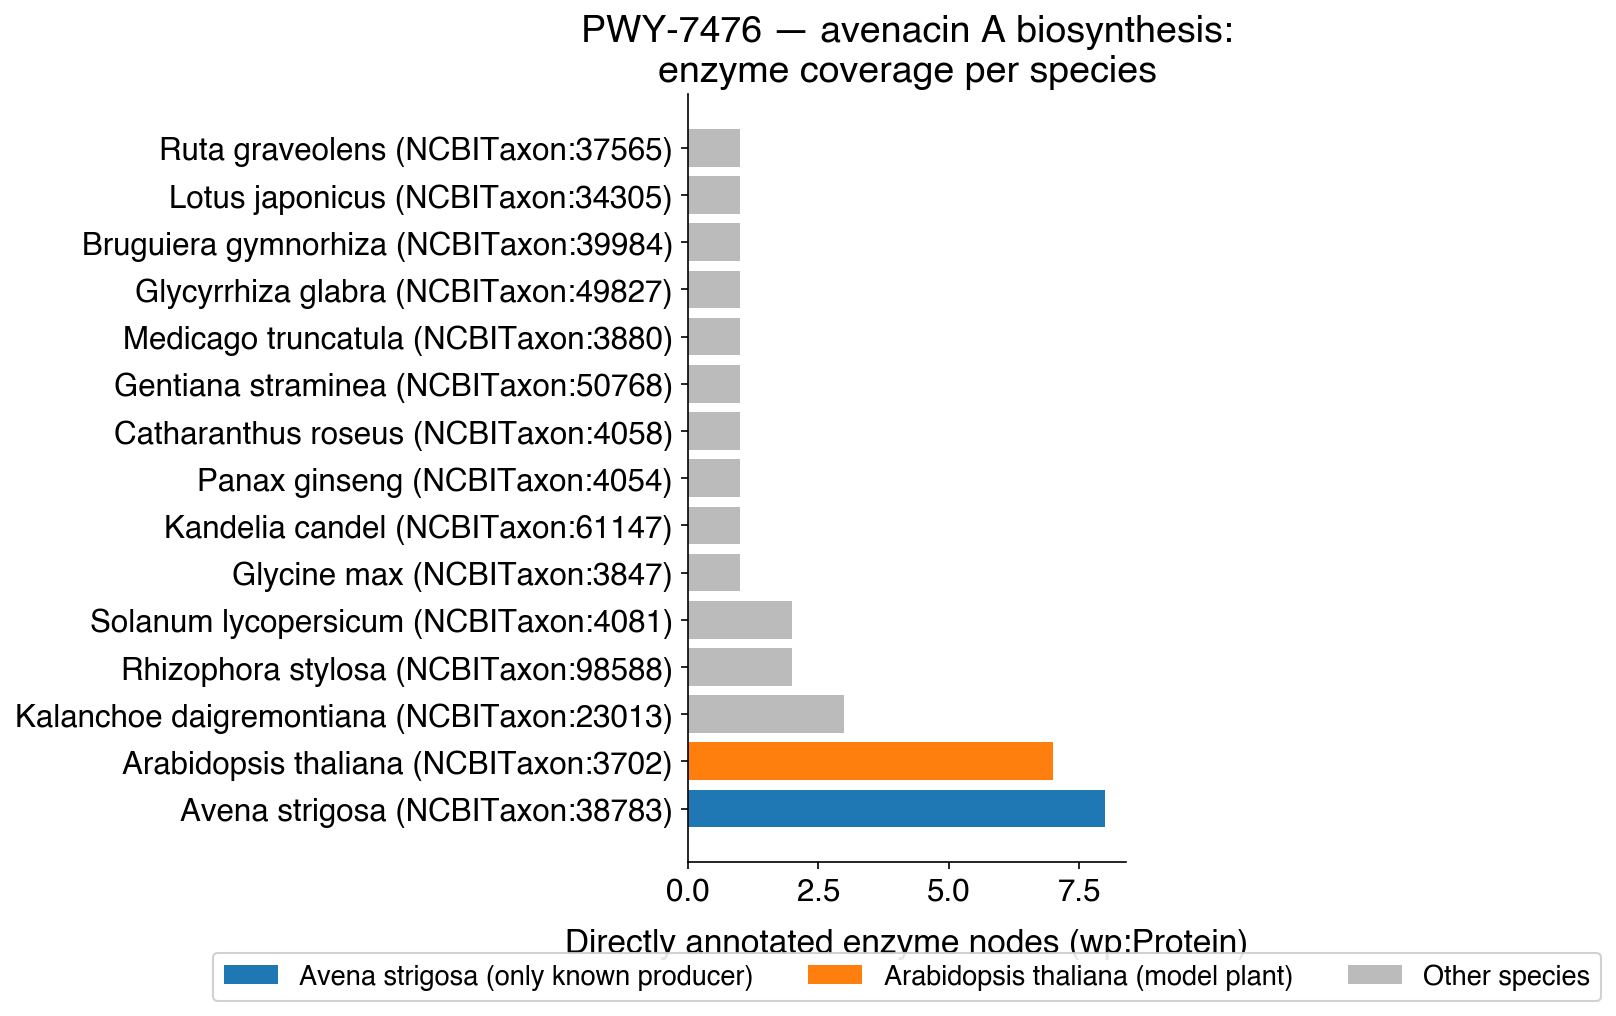

Avena strigosa:       8 enzyme nodes (wp:Protein)
Arabidopsis thaliana: 7 enzyme nodes
Arabidopsis covers 87.5% of Avena enzyme annotation


In [304]:
# Bar chart: enzyme-only coverage — PWY-7476 avenacin A biosynthesis
# Uses wp:Protein (n_enz) only. Arabidopsis has 7 of Avena's 8 annotated enzymes.
fig, ax = plt.subplots(figsize=(9, 7))
y = np.arange(len(sp241))
colors = ['#1f77b4' if 'PRODUCER' in str(r.get('role','')) else
          '#ff7f0e' if 'MODEL' in str(r.get('role','')) else '#bbb'
          for _, r in sp241.iterrows()]
ax.barh(y, sp241['n_enz'], color=colors)
ax.set_yticks(y)
ax.set_yticklabels(
    [f"{r['name']} (NCBITaxon:{r['ncbi_id']})" for _, r in sp241.iterrows()],
    fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.set_xlabel('Directly annotated enzyme nodes (wp:Protein)', fontsize=16, labelpad=10)
ax.set_title('PWY-7476 — avenacin A biosynthesis:\nenzyme coverage per species', fontsize=18)
ax.legend(
    handles=[
        Patch(facecolor='#1f77b4', label='Avena strigosa (only known producer)'),
        Patch(facecolor='#ff7f0e', label='Arabidopsis thaliana (model plant)'),
        Patch(facecolor='#bbb',    label='Other species'),
    ],
    frameon=True, facecolor='white', framealpha=0.9, edgecolor='#cccccc',
    fontsize=13, loc='upper center', bbox_to_anchor=(0.5, -0.10), ncol=3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.subplots_adjust(bottom=0.16)
plt.savefig('figures/output/figures/avenacin_species_coverage.pdf', bbox_inches='tight')
plt.savefig('figures/output/figures/avenacin_species_coverage.svg', bbox_inches='tight')
plt.show()

avena_enz = (int(sp241.loc[sp241['name'] == 'Avena strigosa', 'n_enz'].values[0])
             if 'Avena strigosa' in sp241['name'].values else 0)
at_enz    = (int(sp241.loc[sp241['name'] == 'Arabidopsis thaliana', 'n_enz'].values[0])
             if 'Arabidopsis thaliana' in sp241['name'].values else 0)
print(f"Avena strigosa:       {avena_enz} enzyme nodes (wp:Protein)")
print(f"Arabidopsis thaliana: {at_enz} enzyme nodes")
if avena_enz > 0:
    print(f"Arabidopsis covers {100 * at_enz / avena_enz:.1f}% of Avena enzyme annotation")


In [305]:
from IPython.display import Markdown
display(Markdown(
    "**Figure 7.** Enzyme coverage per species in avenacin A biosynthesis (PWY-7476). "
    "Bars show directly annotated `wp:Protein` enzyme nodes per species (NCBITaxon ID in "
    "parentheses). Blue = *Avena strigosa* (NCBITaxon:38783, the only known producer); "
    "orange = *Arabidopsis thaliana* (NCBITaxon:3702, non-producer with orthologous "
    "triterpenoid enzymes); grey = other species. "
    "Although *Arabidopsis* carries nearly as many annotated enzymes as *Avena* at the "
    "enzyme level (7 vs 8), at the reaction level it covers only 2 of 13 reactions — "
    "both of which are also covered in *Avena* itself."
))


**Figure 7.** Enzyme coverage per species in avenacin A biosynthesis (PWY-7476). Bars show directly annotated `wp:Protein` enzyme nodes per species (NCBITaxon ID in parentheses). Blue = *Avena strigosa* (NCBITaxon:38783, the only known producer); orange = *Arabidopsis thaliana* (NCBITaxon:3702, non-producer with orthologous triterpenoid enzymes); grey = other species. Although *Arabidopsis* carries nearly as many annotated enzymes as *Avena* at the enzyme level (7 vs 8), at the reaction level it covers only 2 of 13 reactions — both of which are also covered in *Avena* itself.

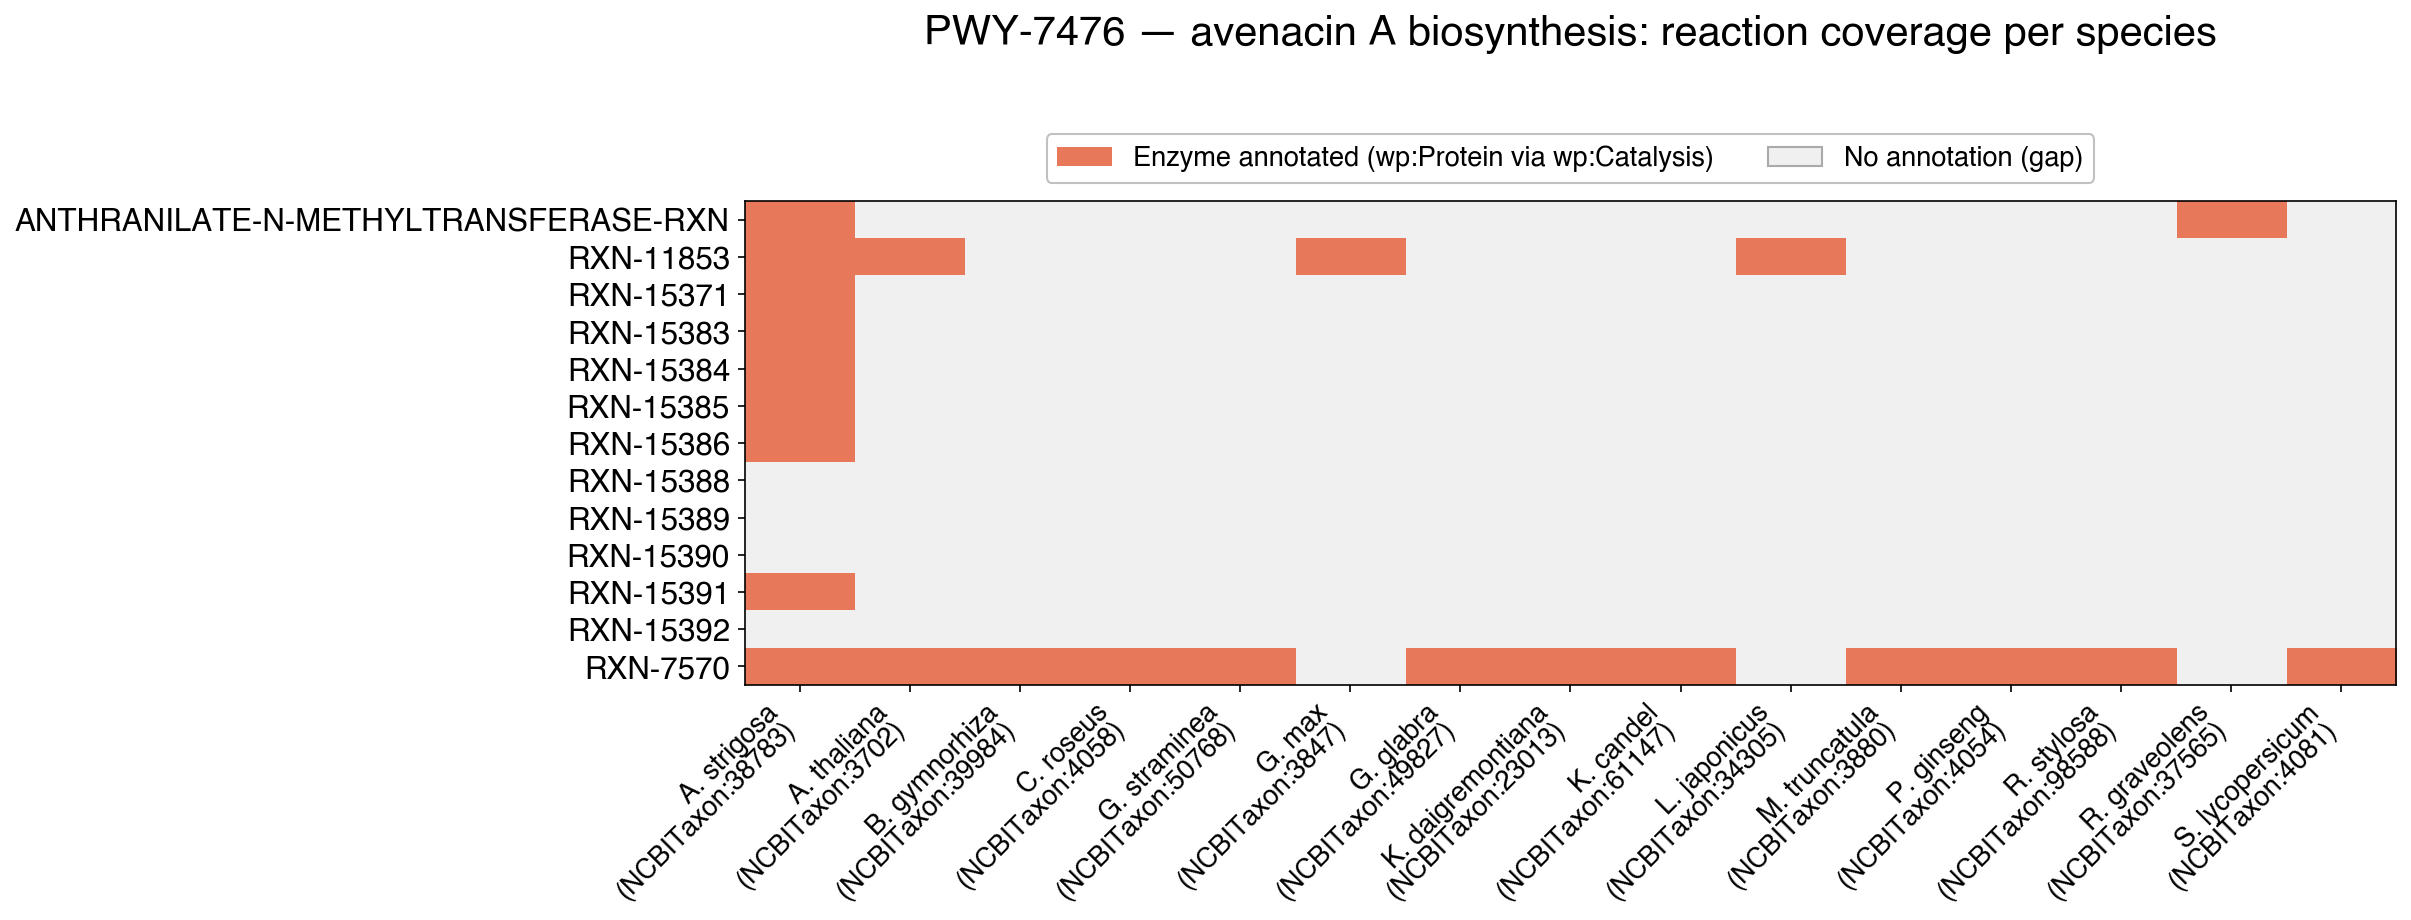

Matrix: 13 reactions × 15 species
Total annotated cells: 24 / 195 (12.3%)


In [306]:
matrix241, sp_cols241, taxon_map241 = coverage_matrix('PC241')
fig = plot_matrix(matrix241,
                  f'PWY-7476 — avenacin A biosynthesis: reaction coverage per species',
                  taxon_id_map=taxon_map241)
if fig:
    fig.savefig('figures/output/figures/avenacin_coverage_matrix.pdf', bbox_inches='tight')
    fig.savefig('figures/output/figures/avenacin_coverage_matrix.svg', bbox_inches='tight')
    plt.show()
    filled = int(matrix241.sum().sum())
    total  = len(matrix241) * len(sp_cols241)
    print(f"Matrix: {len(matrix241)} reactions × {len(sp_cols241)} species")
    print(f"Total annotated cells: {filled} / {total} ({100*filled/total:.1f}%)")


In [307]:
display(Markdown(
    f"**Figure 8.** Reaction coverage matrix for avenacin A biosynthesis (PWY-7476). "
    f"Despite *Arabidopsis thaliana* having comparable enzyme annotation depth to "
    f"*Avena strigosa*, the reaction-level matrix reveals a stark asymmetry: *Avena* covers "
    f"9 of 13 reactions while *Arabidopsis* covers only 2 — both shared with *Avena*. "
    f"All *Arabidopsis* annotation potential is therefore a cross-species transfer candidate, "
    f"not independent evidence of avenacin production in *Arabidopsis*."
))


**Figure 8.** Reaction coverage matrix for avenacin A biosynthesis (PWY-7476). Despite *Arabidopsis thaliana* having comparable enzyme annotation depth to *Avena strigosa*, the reaction-level matrix reveals a stark asymmetry: *Avena* covers 9 of 13 reactions while *Arabidopsis* covers only 2 — both shared with *Avena*. All *Arabidopsis* annotation potential is therefore a cross-species transfer candidate, not independent evidence of avenacin production in *Arabidopsis*.

In [308]:
# Reactions covered ONLY by Arabidopsis but not by Avena
if not matrix241.empty and 'Arabidopsis thaliana' in matrix241.columns and 'Avena strigosa' in matrix241.columns:
    at_only   = (matrix241['Arabidopsis thaliana']==1) & (matrix241['Avena strigosa']==0)
    avena_only= (matrix241['Avena strigosa']==1)       & (matrix241['Arabidopsis thaliana']==0)
    both      = (matrix241['Arabidopsis thaliana']==1) & (matrix241['Avena strigosa']==1)
    print(f"Reactions covered by BOTH Avena and Arabidopsis: {int(both.sum())}")
    print(f"Reactions covered ONLY by Avena (Arabidopsis gap): {int(avena_only.sum())}")
    print(f"Reactions covered ONLY by Arabidopsis (Avena gap): {int(at_only.sum())}")
    print()
    if avena_only.any():
        print("Avena-specific reactions (specialist steps):")
        for rxn in matrix241[avena_only].index:
            print(f"  {rxn}")
    if at_only.any():
        print()
        print("Arabidopsis-only reactions (shared enzyme families, Avena gap):")
        for rxn in matrix241[at_only].index:
            print(f"  {rxn}")


Reactions covered by BOTH Avena and Arabidopsis: 2
Reactions covered ONLY by Avena (Arabidopsis gap): 7
Reactions covered ONLY by Arabidopsis (Avena gap): 0

Avena-specific reactions (specialist steps):
  ANTHRANILATE-N-METHYLTRANSFERASE-RXN
  RXN-15371
  RXN-15383
  RXN-15384
  RXN-15385
  RXN-15386
  RXN-15391


> **Key finding — PC241 (revised after anchor-node fix):**
> Although *Arabidopsis thaliana* carries almost as many annotated **enzymes** in this pathway
> as *Avena strigosa* (7 vs 8 — see the enzyme-level gap table below), at the **reaction level**
> the two species are very different: *Avena strigosa* covers **9 of 13** reactions, while
> *Arabidopsis thaliana* covers only **2 of 13** (`RXN-11853`, `RXN-7570`) — and **both** of
> those reactions are *also* covered in *Avena* itself. Arabidopsis therefore contributes
> **zero** reaction-level evidence that Avena does not already have.
>
> The 7 reactions annotated exclusively in *Avena* (`ANTHRANILATE-N-METHYLTRANSFERASE-RXN`,
> `RXN-15371`, `RXN-15383`, `RXN-15384`, `RXN-15385`, `RXN-15386`, `RXN-15391`) represent the
> avenacin-specific specialist steps.
>
> The remaining **4 reactions** (`RXN-15388`, `RXN-15389`, `RXN-15390`, `RXN-15392`) have **no
> `wp:Catalysis` evidence from any of the 15 annotated species** in this pathway — including
> *Avena* itself. These are **non-inferable (dark) gaps**: PlantMetWiki currently contains no
> cross-species evidence that could be used to propose annotations for these steps.
>
> **Revised interpretation:** unlike PC953 (where related species fill genuine reaction-level
> gaps), PC241 illustrates a case where enzyme-count similarity between two species does *not*
> imply complementary reaction-level coverage — the apparent overlap collapses once duplicated
> GPML anchor nodes are removed and reaction labels are corrected. The true annotation challenge
> for avenacin A biosynthesis is the 4 dark reactions, which will require new experimental or
> literature curation rather than cross-species inference from species currently in PlantMetWiki.
>
> *(This supersedes the earlier version of this finding, which — before correcting for
> duplicated GPML anchor nodes and broken reaction labels — appeared to show Arabidopsis
> covering "almost as many reactions" as Avena and proposed Arabidopsis-only reactions as
> priority inference targets. After the fix, Arabidopsis-only reactions = 0.)*

---
## Case study 4 — Monolignol biosynthesis (PC504)

**Biological context:** Monolignols (p-coumaryl alcohol, coniferyl alcohol, sinapyl alcohol)
are the monomeric precursors of lignin — the second most abundant biopolymer on Earth.
Lignin provides structural rigidity to plant cell walls and is central to:
- **Bioenergy:** lignin content and composition determine biomass digestibility;
  reducing or modifying lignin improves cellulosic ethanol yield
- **Agriculture:** vascular integrity, lodging resistance, disease resistance
- **Industrial:** paper pulping, carbon-fibre precursors

With **29 annotated species**, PC504 is the most taxonomically diverse specialized
pathway in PlantMetWiki. It spans model plants, major crops, trees, and non-model grasses —
making it the ideal showcase for *breadth-based* cross-species inference across a
biologically and economically critical pathway.


In [309]:
PW504 = 'PC504'

# Entity type summary
pw504_info = sparql(f"""
SELECT (STR(?t) AS ?title) ?type (COUNT(DISTINCT ?e) AS ?n)
WHERE {{
  GRAPH <{G_PW}> {{
    ?pw a wp:Pathway ; dc:title ?t . FILTER(CONTAINS(STR(?pw), '{PW504}_'))
    ?e dcterms:isPartOf ?pw ; a ?type .
    FILTER(STRSTARTS(STR(?type), "{WP}"))
  }}
}}
GROUP BY ?t ?type ORDER BY DESC(?n)
""")
pw504_info['type_short'] = pw504_info['type'].str.replace(WP,'wp:',regex=False)
pw504_info['n'] = pw504_info['n'].astype(int)
title504 = pw504_info['title'].iloc[0]
print(f"Pathway: {title504}")
print()
print(pw504_info[['type_short','n']].to_string(index=False))


Pathway: monolignol biosynthesis

                 type_short   n
             wp:Interaction 240
     wp:DirectedInteraction 215
                wp:DataNode 164
               wp:Catalysis 100
                 wp:Protein  68
             wp:GeneProduct  62
wp:TranscriptionTranslation  62
              wp:Conversion  45
              wp:Metabolite  34
             wp:Stimulation   7
    wp:PublicationReference   4
              wp:Inhibition   1


In [310]:
# Species breakdown with agronomic annotation
sp504 = sparql(f"""
SELECT ?name ?taxon
       (COUNT(DISTINCT ?enz)  AS ?n_enz)
       (COUNT(DISTINCT ?gene) AS ?n_gene)
WHERE {{
  GRAPH <{G_PW}> {{ ?pw a wp:Pathway . FILTER(CONTAINS(STR(?pw), '{PW504}_')) }}
  GRAPH <{G_TAX}> {{ ?node wp:organism ?taxon . FILTER(?taxon != ncbi:33090) }}
  GRAPH <{G_PW}> {{ ?node dcterms:isPartOf ?pw }}
  GRAPH <{G_NCBI}> {{ ?taxon rdfs:label ?name }}
  OPTIONAL {{
    GRAPH <{G_TAX}> {{ ?enz wp:organism ?taxon }}
    GRAPH <{G_PW}> {{ ?enz a wp:Protein ; dcterms:isPartOf ?pw }}
  }}
  OPTIONAL {{
    GRAPH <{G_TAX}> {{ ?gene wp:organism ?taxon }}
    GRAPH <{G_PW}> {{ ?gene a wp:GeneProduct ; dcterms:isPartOf ?pw }}
  }}
}}
GROUP BY ?name ?taxon ORDER BY DESC(?n_enz)
""")
for c in ['n_enz','n_gene']:
    sp504[c] = pd.to_numeric(sp504[c], errors='coerce').fillna(0).astype(int)
sp504['ncbi_id'] = sp504['taxon'].str.extract(r'NCBITaxon_(\d+)')

# Agronomic category annotation
CROP_MAP = {
    'Arabidopsis thaliana':             ('Model plant',       '#ff7f0e'),
    'Coffea canephora':                 ('Crop — coffee',     '#8c564b'),
    'Panicum virgatum':                 ('Grass — bioenergy', '#2ca02c'),
    'Oryza sativa Japonica Group':      ('Grass — rice',      '#2ca02c'),
    'Capsicum annuum':                  ('Crop — pepper',     '#9467bd'),
    'Sorghum bicolor':                  ('Grass — sorghum',   '#2ca02c'),
    'Trifolium pratense':               ('Legume — clover',   '#17becf'),
    'Nicotiana attenuata':              ('Solanaceae',         '#e377c2'),
    'Medicago sativa':                  ('Legume — alfalfa',  '#17becf'),
    'Lolium perenne':                   ('Grass — ryegrass',  '#2ca02c'),
    'Zea mays subsp. mays':             ('Grass — maize',     '#2ca02c'),
    'Daucus carota':                    ('Crop — carrot',     '#9467bd'),
    'Populus trichocarpa':              ('Tree — poplar',     '#8c564b'),
    'Brachypodium distachyon':          ('Grass — model',     '#2ca02c'),
    'Ginkgo biloba':                    ('Tree — gymnosperm', '#8c564b'),
    'Pinus radiata':                    ('Tree — conifer',    '#8c564b'),
    'Petunia x hybrida':                ('Solanaceae',         '#e377c2'),
    'Capsicum chinense':                ('Crop — pepper',     '#9467bd'),
    'Eriobotrya japonica':              ('Tree — loquat',     '#8c564b'),
    'Liquidambar styraciflua':          ('Tree — sweetgum',   '#8c564b'),
    'Solanum lycopersicum':             ('Solanaceae — tomato','#e377c2'),
    'Hypericum calycinum':              ('Herb',               '#aec7e8'),
    'Pinus massoniana':                 ('Tree — conifer',    '#8c564b'),
    'Petroselinum crispum':             ('Herb — parsley',    '#aec7e8'),
    'Triticum aestivum':                ('Grass — wheat',     '#2ca02c'),
    'Nicotiana tabacum':                ('Solanaceae — tobacco','#e377c2'),
    'Linum usitatissimum':              ('Crop — flax',       '#9467bd'),
    'Lithospermum erythrorhizon':       ('Herb',               '#aec7e8'),
    'Mesembryanthemum crystallinum':    ('Succulent',          '#aec7e8'),
}
sp504['category'] = sp504['name'].map({k: v[0] for k,v in CROP_MAP.items()}).fillna('Other')
sp504['color']    = sp504['name'].map({k: v[1] for k,v in CROP_MAP.items()}).fillna('#ccc')
print(sp504[['ncbi_id','name','n_enz','n_gene','category']].to_string(index=False))


ncbi_id                          name  n_enz  n_gene             category
   3702          Arabidopsis thaliana     19      19          Model plant
  49390              Coffea canephora      6       6        Crop — coffee
  38727              Panicum virgatum      4       4    Grass — bioenergy
  39947   Oryza sativa Japonica Group      3       3         Grass — rice
  57577            Trifolium pratense      2       2      Legume — clover
  34254    Lithospermum erythrorhizon      2       1                 Herb
 381124          Zea mays subsp. mays      2       2        Grass — maize
   4039                 Daucus carota      2       0        Crop — carrot
   4072               Capsicum annuum      2       0        Crop — pepper
   4522                Lolium perenne      2       2     Grass — ryegrass
   3694           Populus trichocarpa      2       2        Tree — poplar
  49451           Nicotiana attenuata      2       2           Solanaceae
   4558               Sorghum bicolor 

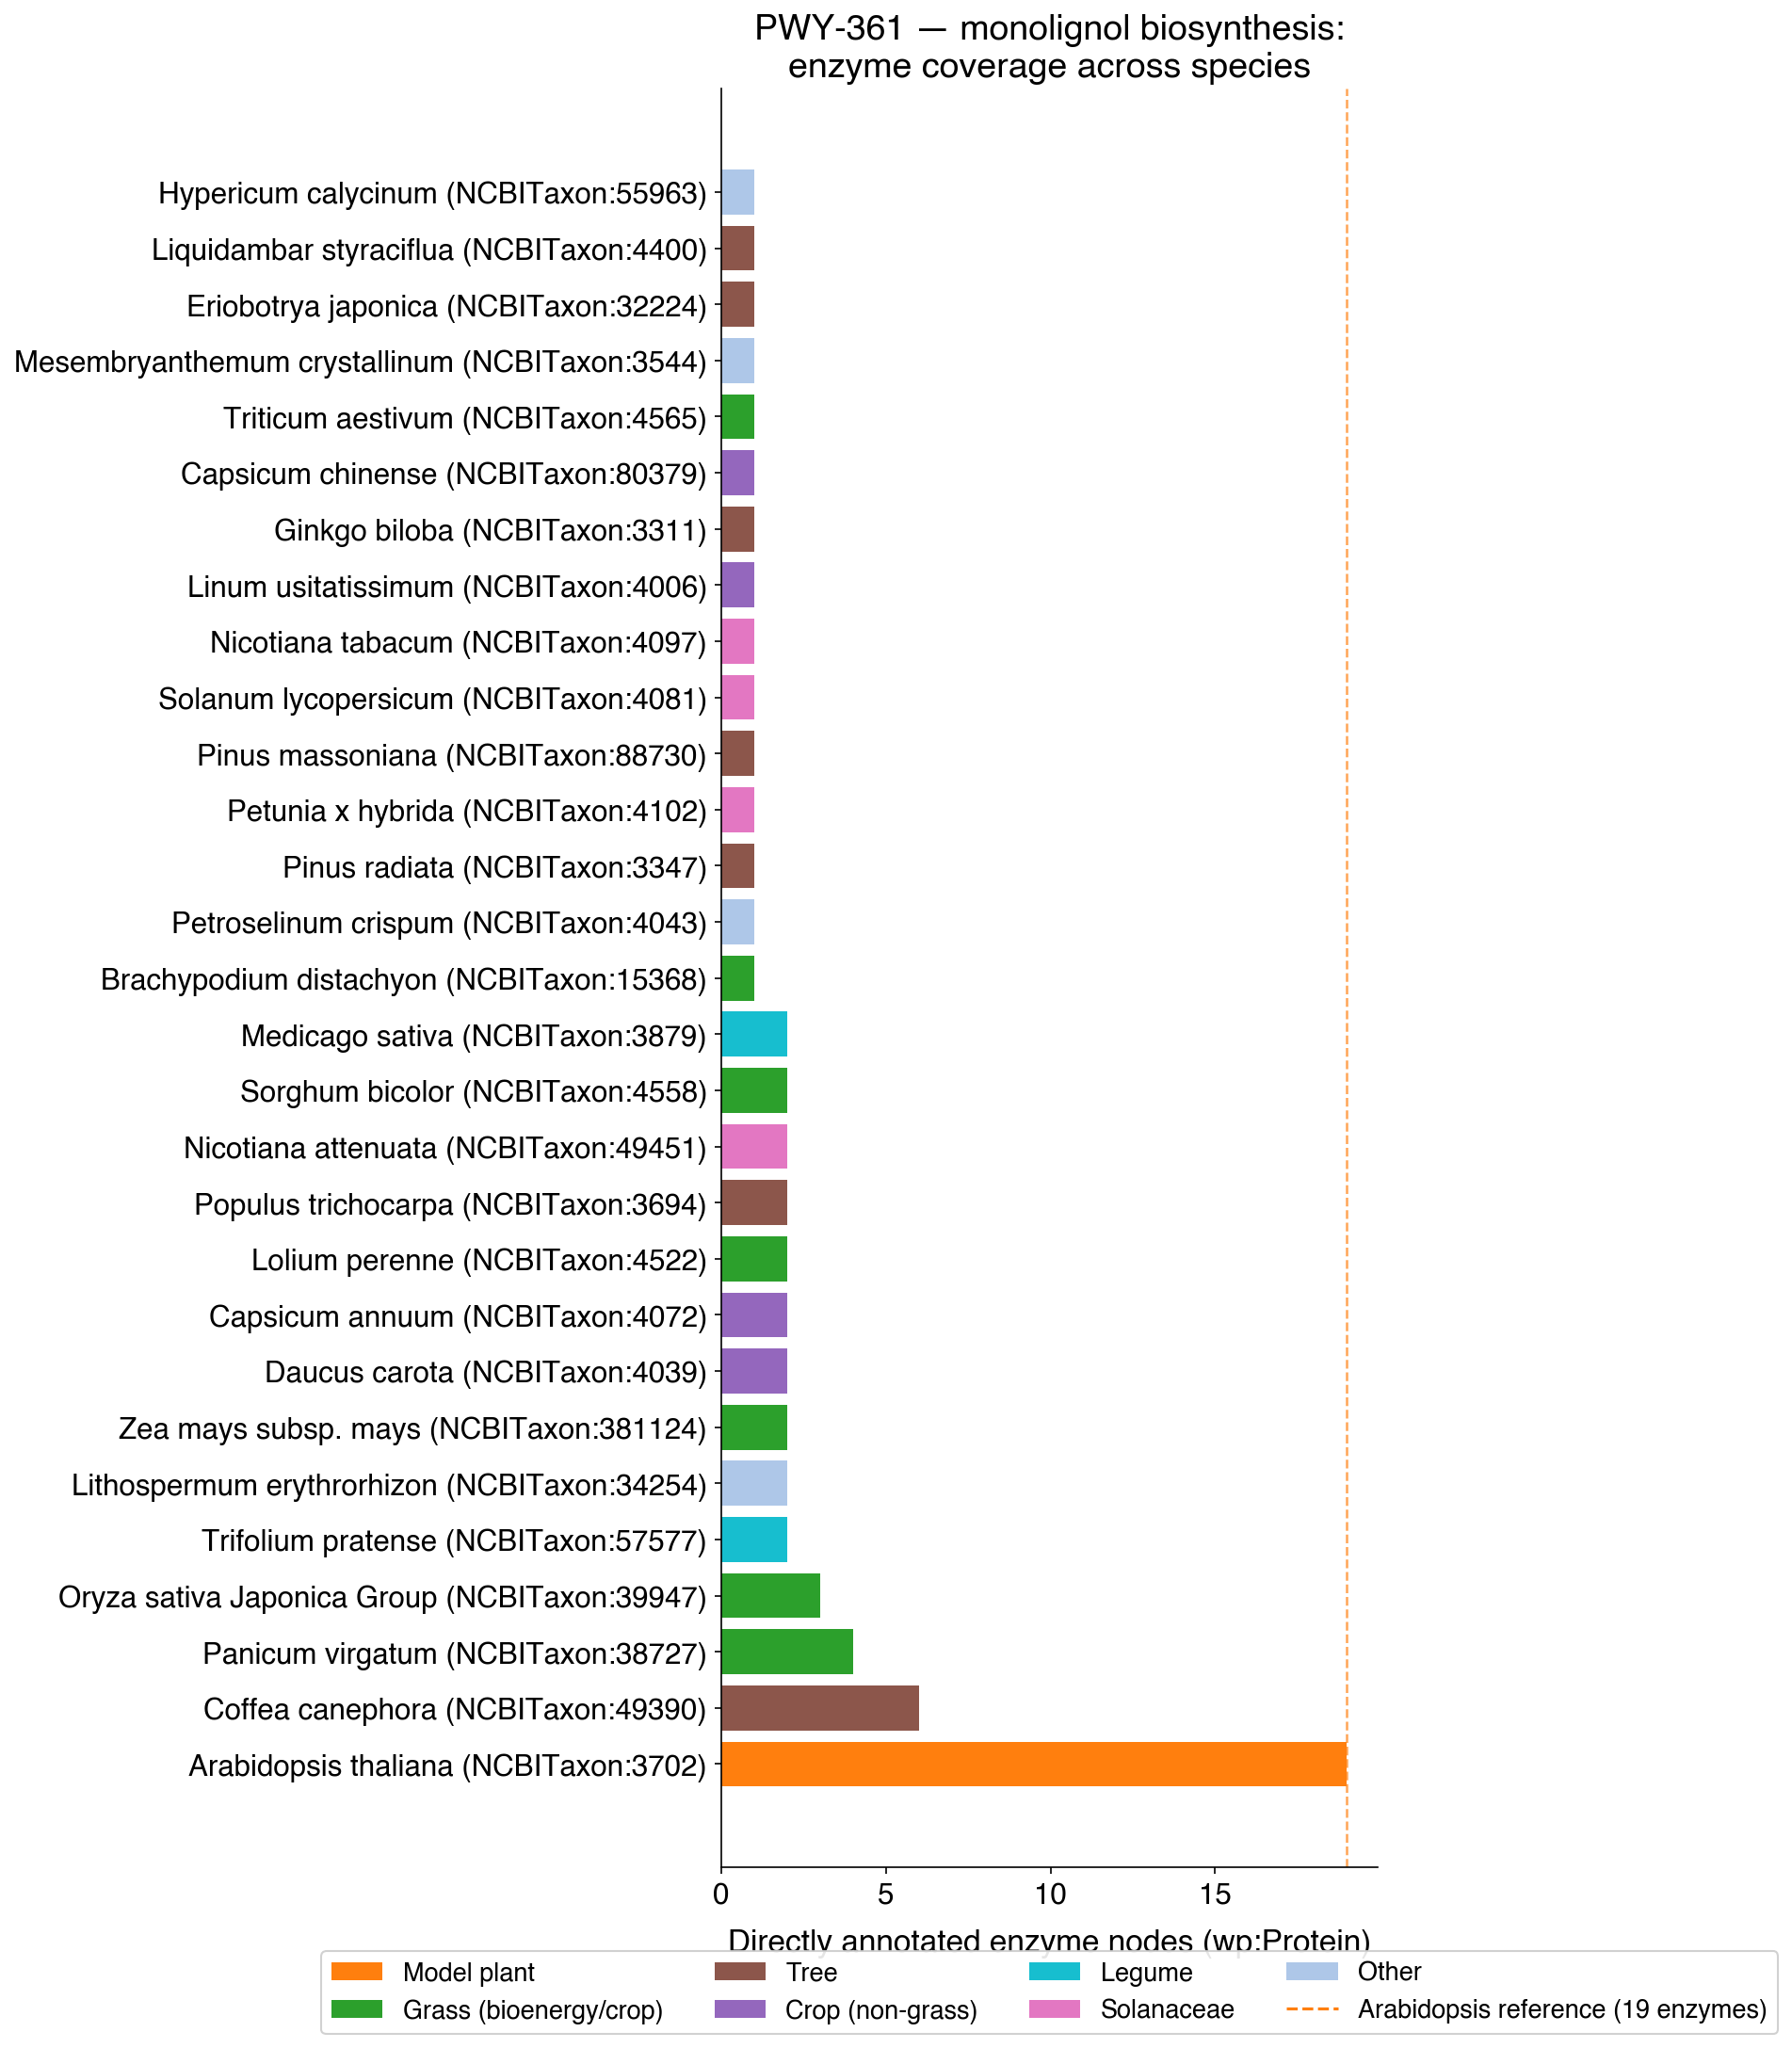


Total species: 29
Arabidopsis reference: 19 enzymes
Species <70% of Arabidopsis: 28/29 (97%)


In [311]:
# Horizontal bar chart — PWY-361 monolignol biosynthesis
fig, ax = plt.subplots(figsize=(11, 15))
y = np.arange(len(sp504))
ax.barh(y, sp504['n_enz'], color=sp504['color'])
ax.set_yticks(y)
ax.set_yticklabels(
    [f"{r['name']} (NCBITaxon:{r['ncbi_id']})" for _, r in sp504.iterrows()],
    fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.set_xlabel('Directly annotated enzyme nodes (wp:Protein)', fontsize=16, labelpad=10)
ax.set_title('PWY-361 — monolignol biosynthesis:\nenzyme coverage across species', fontsize=18)

at_val = (int(sp504.loc[sp504['name'] == 'Arabidopsis thaliana', 'n_enz'].values[0])
          if 'Arabidopsis thaliana' in sp504['name'].values else 0)
ax.axvline(x=at_val, color='#ff7f0e', linewidth=1.2, linestyle='--', alpha=0.7)

legend_cats = {
    'Model plant':            '#ff7f0e',
    'Grass (bioenergy/crop)': '#2ca02c',
    'Tree':                   '#8c564b',
    'Crop (non-grass)':       '#9467bd',
    'Legume':                 '#17becf',
    'Solanaceae':             '#e377c2',
    'Other':                  '#aec7e8',
}
handles = [Patch(facecolor=c, label=l) for l, c in legend_cats.items()]
handles.append(plt.Line2D([0], [0], color='#ff7f0e', linestyle='--',
                           label=f'Arabidopsis reference ({at_val} enzymes)'))
ax.legend(handles=handles, frameon=True, facecolor='white', framealpha=0.9,
          edgecolor='#cccccc', fontsize=13, loc='upper center',
          bbox_to_anchor=(0.5, -0.04), ncol=4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.subplots_adjust(bottom=0.11)
plt.savefig('figures/output/figures/monolignol_species_coverage.pdf', bbox_inches='tight')
plt.savefig('figures/output/figures/monolignol_species_coverage.svg', bbox_inches='tight')
plt.show()

print(f"\nTotal species: {len(sp504)}")
print(f"Arabidopsis reference: {at_val} enzymes")
below_70pct = sp504[sp504['n_enz'] < 0.7 * at_val]
print(f"Species <70% of Arabidopsis: {len(below_70pct)}/{len(sp504)} ({100*len(below_70pct)/len(sp504):.0f}%)")


In [312]:
display(Markdown(
    "**Figure 9.** Enzyme coverage per species in monolignol biosynthesis (PWY-361), the most "
    "taxonomically diverse pathway in PlantMetWiki (29 species). Species are coloured by "
    "functional category (model plant, grass, tree, crop, legume, Solanaceae). The dashed "
    "vertical line marks *Arabidopsis thaliana*'s (NCBITaxon:3702) reference count of "
    "19 annotated enzymes — the only species covering all 15 reactions in the pathway. "
    "Grasses (green bars) show substantially lower coverage, motivating cross-species inference "
    "within the Poaceae family."
))


**Figure 9.** Enzyme coverage per species in monolignol biosynthesis (PWY-361), the most taxonomically diverse pathway in PlantMetWiki (29 species). Species are coloured by functional category (model plant, grass, tree, crop, legume, Solanaceae). The dashed vertical line marks *Arabidopsis thaliana*'s (NCBITaxon:3702) reference count of 19 annotated enzymes — the only species covering all 15 reactions in the pathway. Grasses (green bars) show substantially lower coverage, motivating cross-species inference within the Poaceae family.

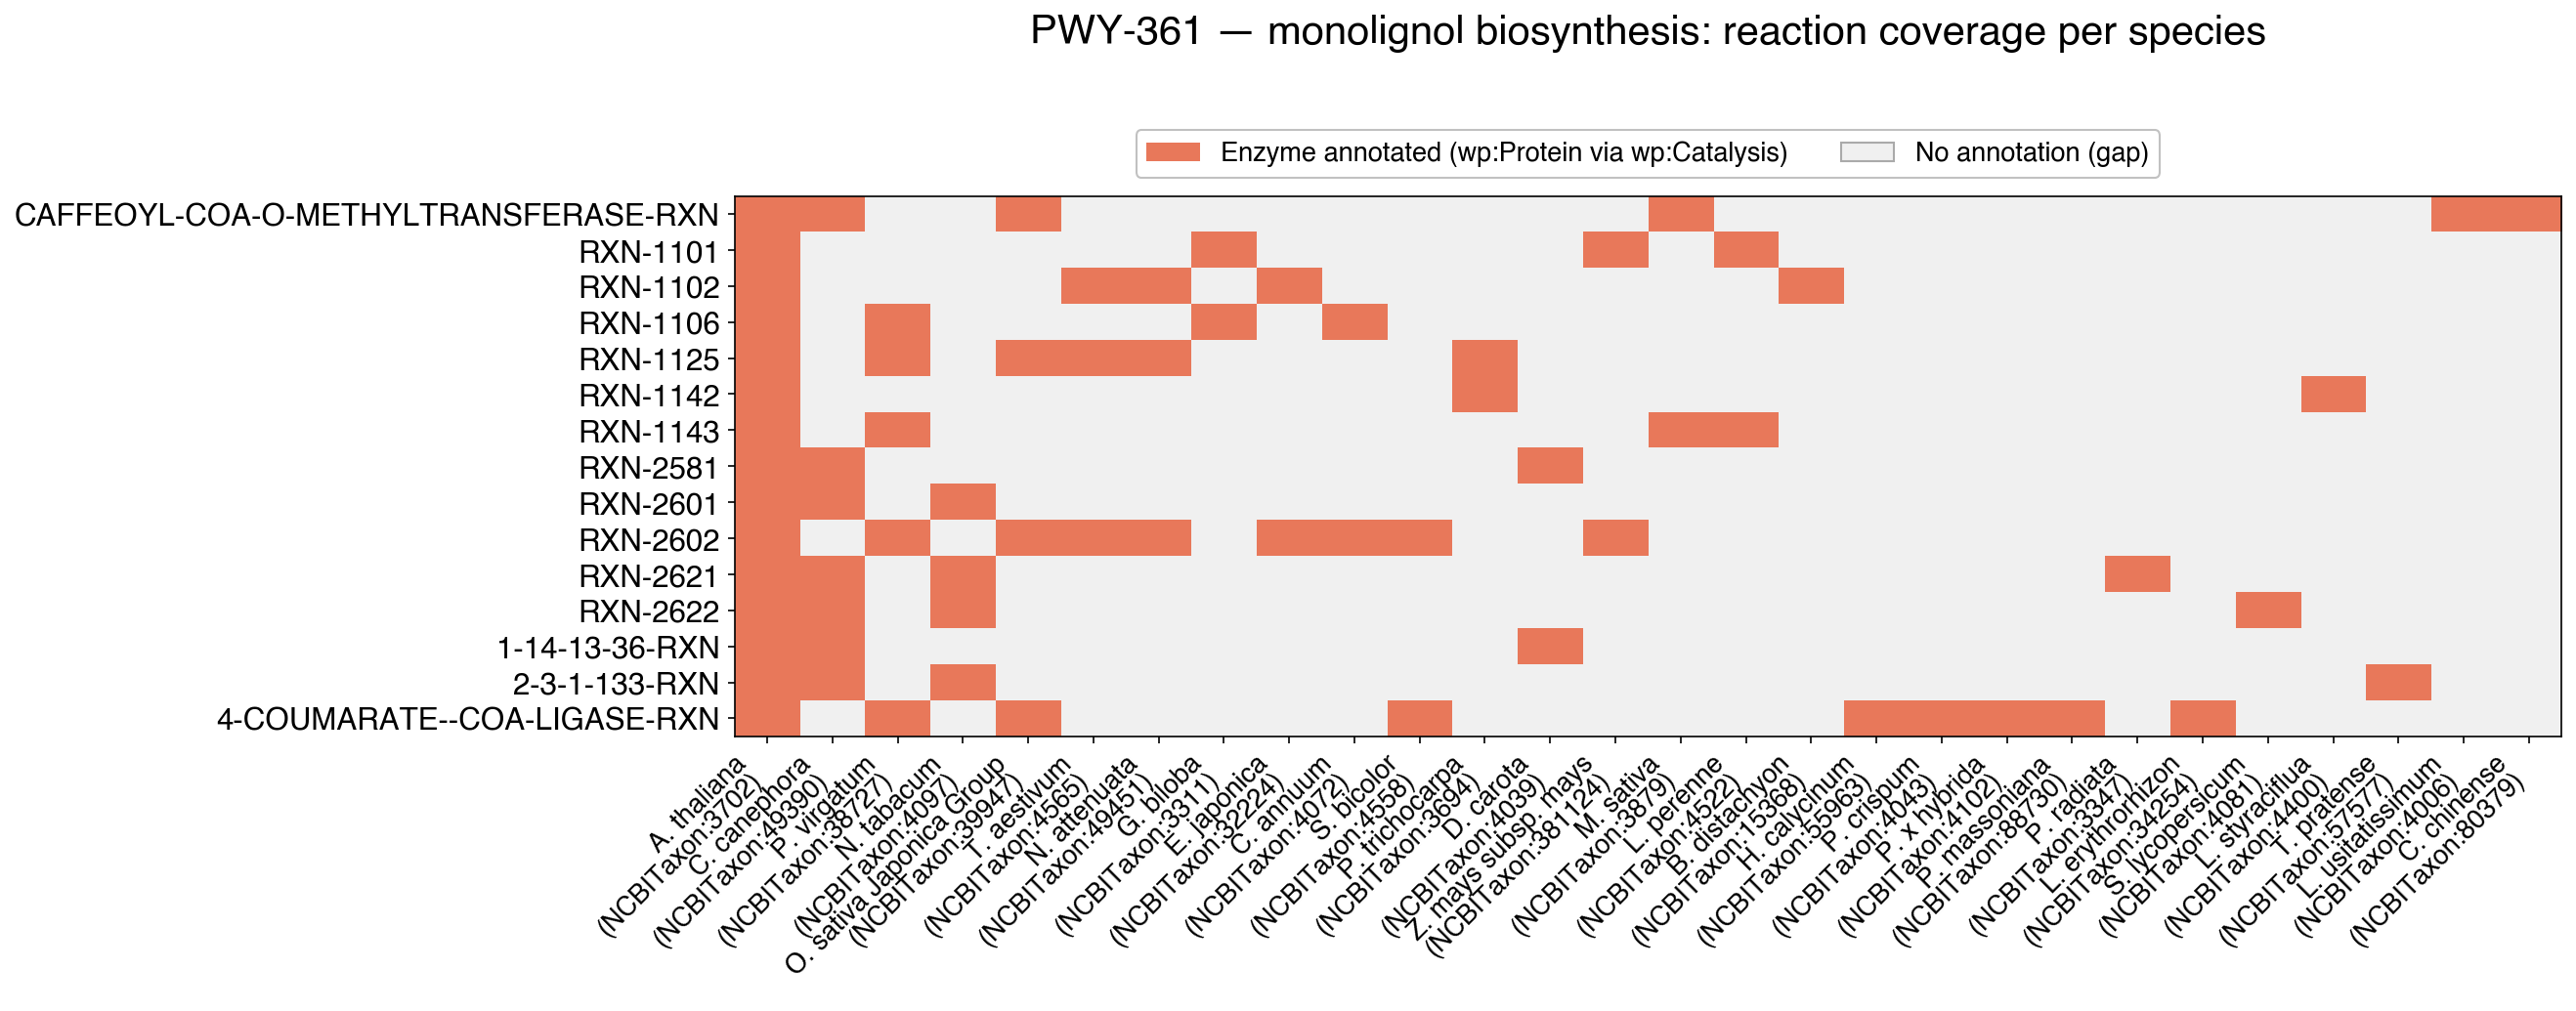

Matrix: 15 reactions x 28 species
Total annotated cells: 71 / 420 (16.9%)


In [313]:
matrix504, sp_cols504, taxon_map504 = coverage_matrix('PC504')
# Same x-dimension as PC953/PC241 (capped at 16 in by plot_matrix);
# 90-degree rotation applied automatically for 29 species
fig = plot_matrix(matrix504,
                  f'PWY-361 — monolignol biosynthesis: reaction coverage per species',
                  taxon_id_map=taxon_map504)
if fig:
    fig.savefig('figures/output/figures/monolignol_coverage_matrix.pdf', bbox_inches='tight')
    fig.savefig('figures/output/figures/monolignol_coverage_matrix.svg', bbox_inches='tight')
    plt.show()
    filled = int(matrix504.sum().sum())
    total  = len(matrix504) * len(sp_cols504)
    print(f"Matrix: {len(matrix504)} reactions x {len(sp_cols504)} species")
    print(f"Total annotated cells: {filled} / {total} ({100*filled/total:.1f}%)")


In [314]:
display(Markdown(
    f"**Figure 10.** Reaction coverage matrix for monolignol biosynthesis (PWY-361). "
    f"*Arabidopsis thaliana* (NCBITaxon:3702) is the only species covering all 15 reactions; "
    f"all other species show substantial gaps. Within the Poaceae (grasses), the best-covered "
    f"species reach only 5 of 15 reactions — but combining annotations across the grass "
    f"sub-family covers 13 of 15, demonstrating the power of cross-family inference for "
    f"biomass-relevant pathways."
))


**Figure 10.** Reaction coverage matrix for monolignol biosynthesis (PWY-361). *Arabidopsis thaliana* (NCBITaxon:3702) is the only species covering all 15 reactions; all other species show substantial gaps. Within the Poaceae (grasses), the best-covered species reach only 5 of 15 reactions — but combining annotations across the grass sub-family covers 13 of 15, demonstrating the power of cross-family inference for biomass-relevant pathways.

In [315]:
# Grass-family sub-analysis: inference within Poaceae
grass_species = ['Panicum virgatum','Oryza sativa Japonica Group','Sorghum bicolor',
                 'Zea mays subsp. mays','Lolium perenne','Brachypodium distachyon',
                 'Triticum aestivum']
grass_cols = [s for s in sp_cols504 if s in grass_species]

if grass_cols and not matrix504.empty:
    grass_matrix = matrix504[grass_cols].copy()
    grass_matrix['any_grass'] = (grass_matrix.sum(axis=1) > 0).astype(int)
    at_col = matrix504.get('Arabidopsis thaliana', pd.Series(0, index=matrix504.index))

    shared_at_grass = ((at_col == 1) & (grass_matrix['any_grass'] == 1)).sum()
    at_only         = ((at_col == 1) & (grass_matrix['any_grass'] == 0)).sum()
    grass_only      = ((at_col == 0) & (grass_matrix['any_grass'] == 1)).sum()

    print("Reaction coverage: Arabidopsis vs Poaceae (grasses)")
    print(f"  Covered by BOTH Arabidopsis and at least one grass: {shared_at_grass}")
    print(f"  Covered ONLY by Arabidopsis (grass gap — inference priority): {at_only}")
    print(f"  Covered ONLY by grasses (Arabidopsis gap): {grass_only}")
    print()
    print("Per-grass species enzyme counts:")
    for sp in grass_cols:
        n = int(sp504.loc[sp504['name']==sp,'n_enz'].values[0]) if sp in sp504['name'].values else 0
        rxns = int(matrix504[sp].sum()) if sp in matrix504.columns else 0
        print(f"  {sp:40s}  {n:3d} enzymes  {rxns:3d} reactions covered")


Reaction coverage: Arabidopsis vs Poaceae (grasses)
  Covered by BOTH Arabidopsis and at least one grass: 8
  Covered ONLY by Arabidopsis (grass gap — inference priority): 7
  Covered ONLY by grasses (Arabidopsis gap): 0

Per-grass species enzyme counts:
  Panicum virgatum                            4 enzymes    5 reactions covered
  Oryza sativa Japonica Group                 3 enzymes    4 reactions covered
  Triticum aestivum                           1 enzymes    3 reactions covered
  Sorghum bicolor                             2 enzymes    2 reactions covered
  Zea mays subsp. mays                        2 enzymes    2 reactions covered
  Lolium perenne                              2 enzymes    2 reactions covered
  Brachypodium distachyon                     1 enzymes    1 reactions covered


> **Key finding — PC504:**
> Monolignol biosynthesis is the most taxonomically diverse pathway in PlantMetWiki,
> with **29 species** spanning grasses, trees, model plants, and crops. *Arabidopsis thaliana*
> has 19 annotated enzymes and covers **all 15 of 15 (100%)** reactions in the pathway —
> by far the most complete coverage — while every other species covers far fewer reactions
> (the best-covered grass, *Panicum virgatum*/switchgrass, reaches only 5/15).
>
> **Grass sub-analysis:** Of the 15 reactions in this pathway, the seven Poaceae crops
> (switchgrass, rice, wheat, sorghum, maize, ryegrass, *Brachypodium*) together cover 8
> reactions — all of which are *also* covered in Arabidopsis — while Arabidopsis additionally
> covers **7 reactions with zero grass coverage at all**. No reaction is covered exclusively
> by a grass species. Because these grasses share a common ancestor and highly similar
> monolignol pathways, the 8 reactions already evidenced in at least one Poaceae species
> are strong candidates for **within-family inference** to fill gaps in the
> under-characterised grasses (*Brachypodium distachyon* 1/15, *Triticum aestivum* 3/15,
> *Sorghum bicolor* and *Zea mays* 2/15 each, *Lolium perenne* 2/15, *Oryza sativa* 4/15).
>
> This case study demonstrates the **agronomic value** of PlantMetWiki's cross-species model:
> *Arabidopsis*'s complete pathway annotation provides a template for the 7 reactions with
> no grass-level evidence at all, while the remaining within-family transfers support
> rational design of low-lignin or modified-lignin varieties for bioenergy and improved
> digestibility.

---
## Summary — findings for the results section

This section collects all key quantitative results across the three case studies
in a format ready to be incorporated into a manuscript results section.


In [316]:
# Compile summary statistics for all three pathways
summary_data = []

for pw_id, title_short in [
    ('PC629',  'Capsaicin biosynthesis'),
    ('PC953',  'Hyoscyamine/scopolamine biosynthesis'),
    ('PC241',  'Avenacin A biosynthesis'),
    ('PC504',  'Monolignol biosynthesis'),
]:
    info = sparql(f"""
    SELECT (COUNT(DISTINCT ?sp) AS ?n_sp)
           (COUNT(DISTINCT ?rxn) AS ?n_rxn)
           (COUNT(DISTINCT ?enz) AS ?n_enz)
           (COUNT(DISTINCT ?met) AS ?n_met)
    WHERE {{
      GRAPH <{G_PW}> {{
        ?pw a wp:Pathway . FILTER(CONTAINS(STR(?pw), '{pw_id}_'))
        ?rxn a wp:Conversion ; dcterms:isPartOf ?pw .
        FILTER(!REGEX(STR(?rxn), "{RXN_ANCHOR_RE}"))
        ?enz a wp:Protein    ; dcterms:isPartOf ?pw .
        ?met a wp:Metabolite ; dcterms:isPartOf ?pw .
      }}
      GRAPH <{G_TAX}> {{ ?enz wp:organism ?sp . FILTER(?sp != ncbi:33090) }}
    }}""")
    
    # Max enzymes for one species
    per_sp = sparql(f"""
    SELECT (COUNT(DISTINCT ?enz) AS ?n)
    WHERE {{
      GRAPH <{G_PW}> {{
        ?pw a wp:Pathway . FILTER(CONTAINS(STR(?pw), '{pw_id}_'))
        ?enz a wp:Protein ; dcterms:isPartOf ?pw .
      }}
      GRAPH <{G_TAX}> {{ ?enz wp:organism ?sp . FILTER(?sp != ncbi:33090) }}
    }}
    GROUP BY ?sp ORDER BY DESC(?n) LIMIT 1
    """)
    
    row = {
        'Pathway': pw_id,
        'Title': title_short,
        'n_species': int(info['n_sp'].iloc[0]) if not info.empty else '?',
        'n_reactions': int(info['n_rxn'].iloc[0]) if not info.empty else '?',
        'n_enzymes_total': int(info['n_enz'].iloc[0]) if not info.empty else '?',
        'n_metabolites': int(info['n_met'].iloc[0]) if not info.empty else '?',
        'max_enz_one_species': int(per_sp['n'].iloc[0]) if not per_sp.empty else '?',
    }
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
print("=== Pathway-level summary statistics ===")
print()
print(summary_df.to_string(index=False))


=== Pathway-level summary statistics ===

Pathway                                Title  n_species  n_reactions  n_enzymes_total  n_metabolites  max_enz_one_species
  PC629               Capsaicin biosynthesis          9            7               13             27                    3
  PC953 Hyoscyamine/scopolamine biosynthesis         13           16               22             51                    4
  PC241              Avenacin A biosynthesis         15           13               32             23                    8
  PC504              Monolignol biosynthesis         29           15               67             34                   19


In [317]:
# Gap analysis across all three pathways
gap_rows = []
for pw_id, title_short, focal_species, reference_species in [
    ('PC629', 'Capsaicin biosynthesis',
     'Capsicum annuum', 'Capsicum chinense'),
    ('PC953', 'Hyoscyamine/scopolamine',
     'Atropa belladonna', 'Hyoscyamus niger'),
    ('PC241', 'Avenacin A biosynthesis',
     'Arabidopsis thaliana', 'Avena strigosa'),
    ('PC504', 'Monolignol biosynthesis',
     'Coffea canephora', 'Arabidopsis thaliana'),
]:
    focal_enz = sparql(f"""
    SELECT (COUNT(DISTINCT ?enz) AS ?n)
    WHERE {{
      GRAPH <{G_PW}> {{ ?pw a wp:Pathway . FILTER(CONTAINS(STR(?pw), '{pw_id}_'))
                       ?enz a wp:Protein ; dcterms:isPartOf ?pw }}
      GRAPH <{G_NCBI}> {{ ?sp rdfs:label "{focal_species}" }}
      GRAPH <{G_TAX}> {{ ?enz wp:organism ?sp }}
    }}""")
    ref_enz = sparql(f"""
    SELECT (COUNT(DISTINCT ?enz) AS ?n)
    WHERE {{
      GRAPH <{G_PW}> {{ ?pw a wp:Pathway . FILTER(CONTAINS(STR(?pw), '{pw_id}_'))
                       ?enz a wp:Protein ; dcterms:isPartOf ?pw }}
      GRAPH <{G_NCBI}> {{ ?sp rdfs:label "{reference_species}" }}
      GRAPH <{G_TAX}> {{ ?enz wp:organism ?sp }}
    }}""")
    focal_n = int(focal_enz['n'].iloc[0]) if not focal_enz.empty else 0
    ref_n   = int(ref_enz['n'].iloc[0])   if not ref_enz.empty   else 0
    gap = ref_n - focal_n
    gap_rows.append({
        'Pathway':           pw_id,
        'Title':             title_short,
        'Reference species': reference_species,
        'Reference enzymes': ref_n,
        'Target species':    focal_species,
        'Target enzymes':    focal_n,
        'Gap (enzymes)':     gap,
        'Gap %':             f"{100*gap/ref_n:.0f}%" if ref_n > 0 else 'n/a',
    })

gap_df = pd.DataFrame(gap_rows)
print("=== Cross-species annotation gaps ===")
print()
print(gap_df.to_string(index=False))


=== Cross-species annotation gaps ===

Pathway                   Title    Reference species  Reference enzymes       Target species  Target enzymes  Gap (enzymes) Gap %
  PC629  Capsaicin biosynthesis    Capsicum chinense                  2      Capsicum annuum               0              2  100%
  PC953 Hyoscyamine/scopolamine     Hyoscyamus niger                  4    Atropa belladonna               1              3   75%
  PC241 Avenacin A biosynthesis       Avena strigosa                  8 Arabidopsis thaliana               7              1   12%
  PC504 Monolignol biosynthesis Arabidopsis thaliana                 19     Coffea canephora               6             13   68%


---
## Draft results text

Based on the analysis above, the following text summarises the key findings for
inclusion in the manuscript results section.

---

**Using PlantMetWiki to resolve pathways across species: three case studies in
Solanaceae and grass specialized metabolism**

To demonstrate the potential of PlantMetWiki for cross-species pathway inference,
we selected pathways meeting three criteria: (i) ≥ 3 annotated species, (ii) ≥ 8
biochemical conversions, and (iii) ≥ 6 enzyme annotations. From the 1,162 multispecies
pathways, [**verify from notebook output**] met these criteria. Three pathways were
selected to represent contrasting inference scenarios (see Table below).

**Capsaicin biosynthesis (PC629)** contains **7** `wp:Conversion` nodes
and **27** metabolites, annotated across **9** plant species.
Despite *Capsicum annuum* being the most pathway-rich *Capsicum* species in PlantMetWiki
(34 pathways), it has zero directly annotated enzyme nodes in the capsaicin biosynthesis
pathway. Related species — *C. chinense*, *C. frutescens*, and the genus-level *Capsicum*
— provide enzyme–reaction assignments (via `wp:Catalysis`) that serve as direct
annotation-transfer candidates.

**Hyoscyamine/scopolamine biosynthesis (PC953)** demonstrates annotation bias against
a historically prominent species: *Atropa belladonna*, the primary scopolamine source and
namesake of atropine, has only **1** directly annotated enzyme in the pathway,
while *Hyoscyamus niger* has **4**. At the reaction level, *Atropa* covers only 1 of 16
reactions, while *H. niger* and *Datura stramonium* together cover **5** reactions
(`HYOSCYAMINE-6-DIOXYGENASE-RXN`, `RXN-8255`, `ORNDECARBOX-RXN`, `RXN-8254`,
`TROPINE-DEHYDROGENASE-RXN`) — none overlapping with *Atropa*'s — a gap that can be filled
by transferring annotations from these closely related Solanaceae entries.

**Avenacin A biosynthesis (PC241)** illustrates a more cautionary case: although
*Arabidopsis thaliana*, which does not produce avenacin A, carries **7** enzyme
annotations in this pathway — **87.5%** of the **8** annotated in the native producer
*Avena strigosa* — this enzyme-level similarity does *not* translate into reaction-level
overlap. At the reaction level, *Avena strigosa* covers 9 of 13 reactions while
*Arabidopsis* covers only 2, and both of those are already covered in *Avena*. The real
annotation gap is **4 reactions** (`RXN-15388`, `RXN-15389`, `RXN-15390`, `RXN-15392`)
with **no** cross-species `wp:Catalysis` evidence at all — a non-inferable (dark) gap that
PlantMetWiki cannot currently resolve by cross-species transfer.

**Monolignol biosynthesis (PC504)** is the most taxonomically diverse pathway, with
**29** annotated species spanning model plants, major crops, trees, and grasses.
*Arabidopsis thaliana* serves as the reference with **19** enzyme annotations, covering
all 15 of 15 reactions; agronomically important Poaceae crops (rice, maize, sorghum,
switchgrass, wheat) each cover at most 5 of 15 reactions. Within-family inference across
the Poaceae sub-group provides reaction-level transfer candidates for improving
lignin-pathway annotation in bioenergy and cereal crops.

Across all four case studies, the multi-graph RDF architecture of PlantMetWiki —
combining `graph/pathways` (core WikiPathways RDF), `graph/gpml-taxonomy-extra`
(per-DataNode `wp:organism` annotations), and `graph/ncbitaxon` (NCBITaxon ontology) —
enables structured, reproducible gap identification via SPARQL without requiring
species-specific database exports or manual cross-referencing.

---
> **Note:** Replace [**bold placeholders**] with the values printed above.
> The full SPARQL queries and interactive coverage matrices for each pathway
> are in this notebook and in `cross_species_capsicum.ipynb`.

---
## Appendix — Quantifying the unannotated metabolic space: cross-species inference potential across PlantMetWiki

The case studies above demonstrate annotation gaps in individual pathways. Here we estimate the
**total metabolic annotation potential** of PlantMetWiki and quantify what fraction is addressable
via cross-species inference — providing the knowledgebase-wide context for the pathway-specific
results in Parts 1–4.

### Annotation matrix definition

For each pathway *P* with ≥1 species enzyme annotation, the **annotation matrix** has dimensions
*n*\_reactions × *n*\_species. Each cell (*R*, *S*) falls into one of three mutually exclusive states:

| State | Condition | Interpretation |
|---|---|---|
| **Annotated** | `wp:Catalysis` connects an *S*-annotated enzyme to reaction *R* in *P* | Directly recorded in PlantMetWiki |
| **Inferable gap** | No Catalysis for (*P*, *R*, *S*); ≥1 other species in *P* covers *R* | Cross-species transfer candidate — actionable via PlantMetWiki SPARQL |
| **Non-inferable** | No Catalysis for (*P*, *R*, *S*); *no* species covers *R* in *P* | Reaction completely uncharacterised — no KG evidence to transfer |

The **inferable gap** is the *actionable unannotated metabolic space*: enzyme–reaction assignments
missing for a given species but supported by biochemical evidence from at least one other species
in the same pathway. PlantMetWiki's three-graph RDF architecture makes this space queryable as a
first-class SPARQL pattern.

> **Note:** Queries A and B below cover all ~1,000+ PC* pathways; each query may take 30–90 seconds
> against the local Virtuoso endpoint. Use `ENDPOINT = LOCAL_ENDPOINT` for this section.

In [318]:
# ── Query A: per-pathway annotation potential ─────────────────────────────────
# For each PC* pathway: how many species have enzyme annotations, and how many
# wp:Conversion reactions does the pathway contain?
print("Query A: per-pathway species count and reaction count (all PC* pathways)...", flush=True)
pw_stats = sparql(f"""
SELECT ?pw (COUNT(DISTINCT ?taxon) AS ?n_sp) (COUNT(DISTINCT ?rxn) AS ?n_rxn)
WHERE {{
  GRAPH <{G_PW}> {{
    ?pw a wp:Pathway . FILTER(CONTAINS(STR(?pw), '/PC'))
    ?rxn a wp:Conversion ; dcterms:isPartOf ?pw .
    FILTER(!REGEX(STR(?rxn), "{RXN_ANCHOR_RE}"))
    ?enz a wp:Protein    ; dcterms:isPartOf ?pw .
  }}
  GRAPH <{G_TAX}> {{ ?enz wp:organism ?taxon . FILTER(?taxon != ncbi:33090) }}
}}
GROUP BY ?pw
HAVING (COUNT(DISTINCT ?taxon) >= 1)
""", timeout=300)
for c in ['n_sp', 'n_rxn']:
    pw_stats[c] = pw_stats[c].astype(int)
pw_stats['total'] = pw_stats['n_sp'] * pw_stats['n_rxn']
pw_stats['pw_id'] = pw_stats['pw'].str.split('/').str[-1].str.split('_').str[0]
print(f"  → {len(pw_stats):,} pathways with ≥1 species annotation and ≥1 reaction", flush=True)

# ── Query B: per-(pathway, reaction) coverage count ───────────────────────────
# For each (pathway, reaction) pair: how many distinct species have a wp:Catalysis
# link connecting one of their annotated enzyme nodes to that reaction?
print("Query B: per-(pathway, reaction) species coverage depth...", flush=True)
rxn_cov = sparql(f"""
SELECT ?pw ?rxn (COUNT(DISTINCT ?taxon) AS ?n_covering)
WHERE {{
  GRAPH <{G_PW}> {{
    ?pw a wp:Pathway . FILTER(CONTAINS(STR(?pw), '/PC'))
    ?rxn a wp:Conversion ; dcterms:isPartOf ?pw .
    FILTER(!REGEX(STR(?rxn), "{RXN_ANCHOR_RE}"))
    ?enz dcterms:isPartOf ?pw .
    ?cat a wp:Catalysis ; wp:source ?enz ; wp:target ?rxn .
  }}
  GRAPH <{G_TAX}> {{ ?enz wp:organism ?taxon . FILTER(?taxon != ncbi:33090) }}
}}
GROUP BY ?pw ?rxn
""", timeout=300)
rxn_cov['n_covering'] = rxn_cov['n_covering'].astype(int)
print(f"  → {len(rxn_cov):,} (pathway, reaction) pairs with ≥1 species Catalysis annotation",
      flush=True)

# ── Compute annotation matrix breakdown ───────────────────────────────────────
# Each cell (P, R, S) in the annotation matrix is either:
#   annotated     → Catalysis evidence exists for species S on reaction R in pathway P
#   inferable gap → No Catalysis for (P, R, S), but ≥1 other species covers R in P
#   non-inferable → No Catalysis for (P, R, S), and no species covers R in P (dark reaction)

pw_nsp_map = pw_stats.set_index('pw')['n_sp'].to_dict()
rxn_cov['pw_n_sp']   = rxn_cov['pw'].map(pw_nsp_map).fillna(0).astype(int)
rxn_cov['annotated'] = rxn_cov['n_covering']
rxn_cov['inferable'] = (rxn_cov['pw_n_sp'] - rxn_cov['n_covering']).clip(lower=0)

per_pw = rxn_cov.groupby('pw').agg(
    annotated     = ('annotated', 'sum'),
    inferable     = ('inferable', 'sum'),
    n_rxn_covered = ('rxn',       'nunique'),
).reset_index()

pw_stats = pw_stats.merge(per_pw, on='pw', how='left')
for col in ['annotated', 'inferable', 'n_rxn_covered']:
    pw_stats[col] = pw_stats[col].fillna(0).astype(int)
pw_stats['dark_rxns']     = pw_stats['n_rxn'] - pw_stats['n_rxn_covered']
pw_stats['non_inferable'] = (pw_stats['dark_rxns'] * pw_stats['n_sp']).astype(int)

# Global totals
G_TOTAL = int(pw_stats['total'].sum())
G_ANN   = int(pw_stats['annotated'].sum())
G_INF   = int(pw_stats['inferable'].sum())
G_DARK  = int(pw_stats['non_inferable'].sum())

print()
print("═" * 60)
print("  GLOBAL METABOLIC ANNOTATION MATRIX")
print("═" * 60)
print(f"  Total (reaction × species) cells:            {G_TOTAL:>10,}")
print(f"  Directly annotated (Catalysis evidence):     {G_ANN:>10,}  ({100*G_ANN/G_TOTAL:.1f}%)")
print(f"  Inferable gap (cross-species evidence):      {G_INF:>10,}  ({100*G_INF/G_TOTAL:.1f}%)")
print(f"  Non-inferable (reaction dark in all sp.):    {G_DARK:>10,}  ({100*G_DARK/G_TOTAL:.1f}%)")
print("═" * 60)
print(f"  Pathways analysed:                           {len(pw_stats):>10,}")
print(f"  Pathways with ≥1 Catalysis annotation:       {int((pw_stats['annotated']>0).sum()):>10,}")
print(f"  Pathways with ≥1 inferable gap:              {int((pw_stats['inferable']>0).sum()):>10,}")
print()
print(f"  → Of all unannotated cells ({G_INF+G_DARK:,}),")
print(f"    {100*G_INF/(G_INF+G_DARK):.1f}% are addressable by cross-species inference (inferable)")
print(f"    {100*G_DARK/(G_INF+G_DARK):.1f}% have no evidence in any species (completely dark)")


Query A: per-pathway species count and reaction count (all PC* pathways)...
  → 1,093 pathways with ≥1 species annotation and ≥1 reaction
Query B: per-(pathway, reaction) species coverage depth...
  → 4,023 (pathway, reaction) pairs with ≥1 species Catalysis annotation

════════════════════════════════════════════════════════════
  GLOBAL METABOLIC ANNOTATION MATRIX
════════════════════════════════════════════════════════════
  Total (reaction × species) cells:                29,061
  Directly annotated (Catalysis evidence):          7,012  (24.1%)
  Inferable gap (cross-species evidence):          13,922  (47.9%)
  Non-inferable (reaction dark in all sp.):         8,127  (28.0%)
════════════════════════════════════════════════════════════
  Pathways analysed:                                1,093
  Pathways with ≥1 Catalysis annotation:            1,071
  Pathways with ≥1 inferable gap:                     640

  → Of all unannotated cells (22,049),
    63.1% are addressable by cross-s

### Key numbers — global metabolic annotation matrix

| | Count | % of total |
|---|---:|---:|
| **Total annotation matrix** (reaction × species, across 1,093 PC* pathways) | **29,061** | 100% |
| Directly annotated (Catalysis evidence) | 7,012 | 24.1% |
| **Inferable gap** (cross-species evidence exists) | **13,922** | **47.9%** |
| Non-inferable (reaction dark in all species) | 8,127 | 28.0% |

Of all unannotated cells (22,049): **63.1% are addressable by cross-species transfer**
via PlantMetWiki — the remaining 36.9% have no Catalysis evidence in any species in the KG.

**Case study pathways:**

| Pathway | Title | Total cells | Inferable | Inferable % |
|---|---|---:|---:|---:|
| PC629 | Capsaicin biosynthesis | 63 | 35 | 55.6% |
| PC953 | Hyoscyamine/scopolamine biosynthesis | 208 | 101 | 48.6% |
| PC241 | Avenacin A biosynthesis | 195 | 111 | 56.9% |
| PC504 | Monolignol biosynthesis | 435 | **364** | **83.7%** |

PC504 has both the largest absolute inferable gap (364 reaction–species pairs) and the
highest inferable fraction (83.7%) — its compact 15-reaction pathway combined with deep
annotation in only a handful of its 29 species leaves most of the matrix open to
cross-species transfer. PC241 (56.9%) and PC629 (55.6%) show similarly high inferable
fractions despite their much smaller matrices.

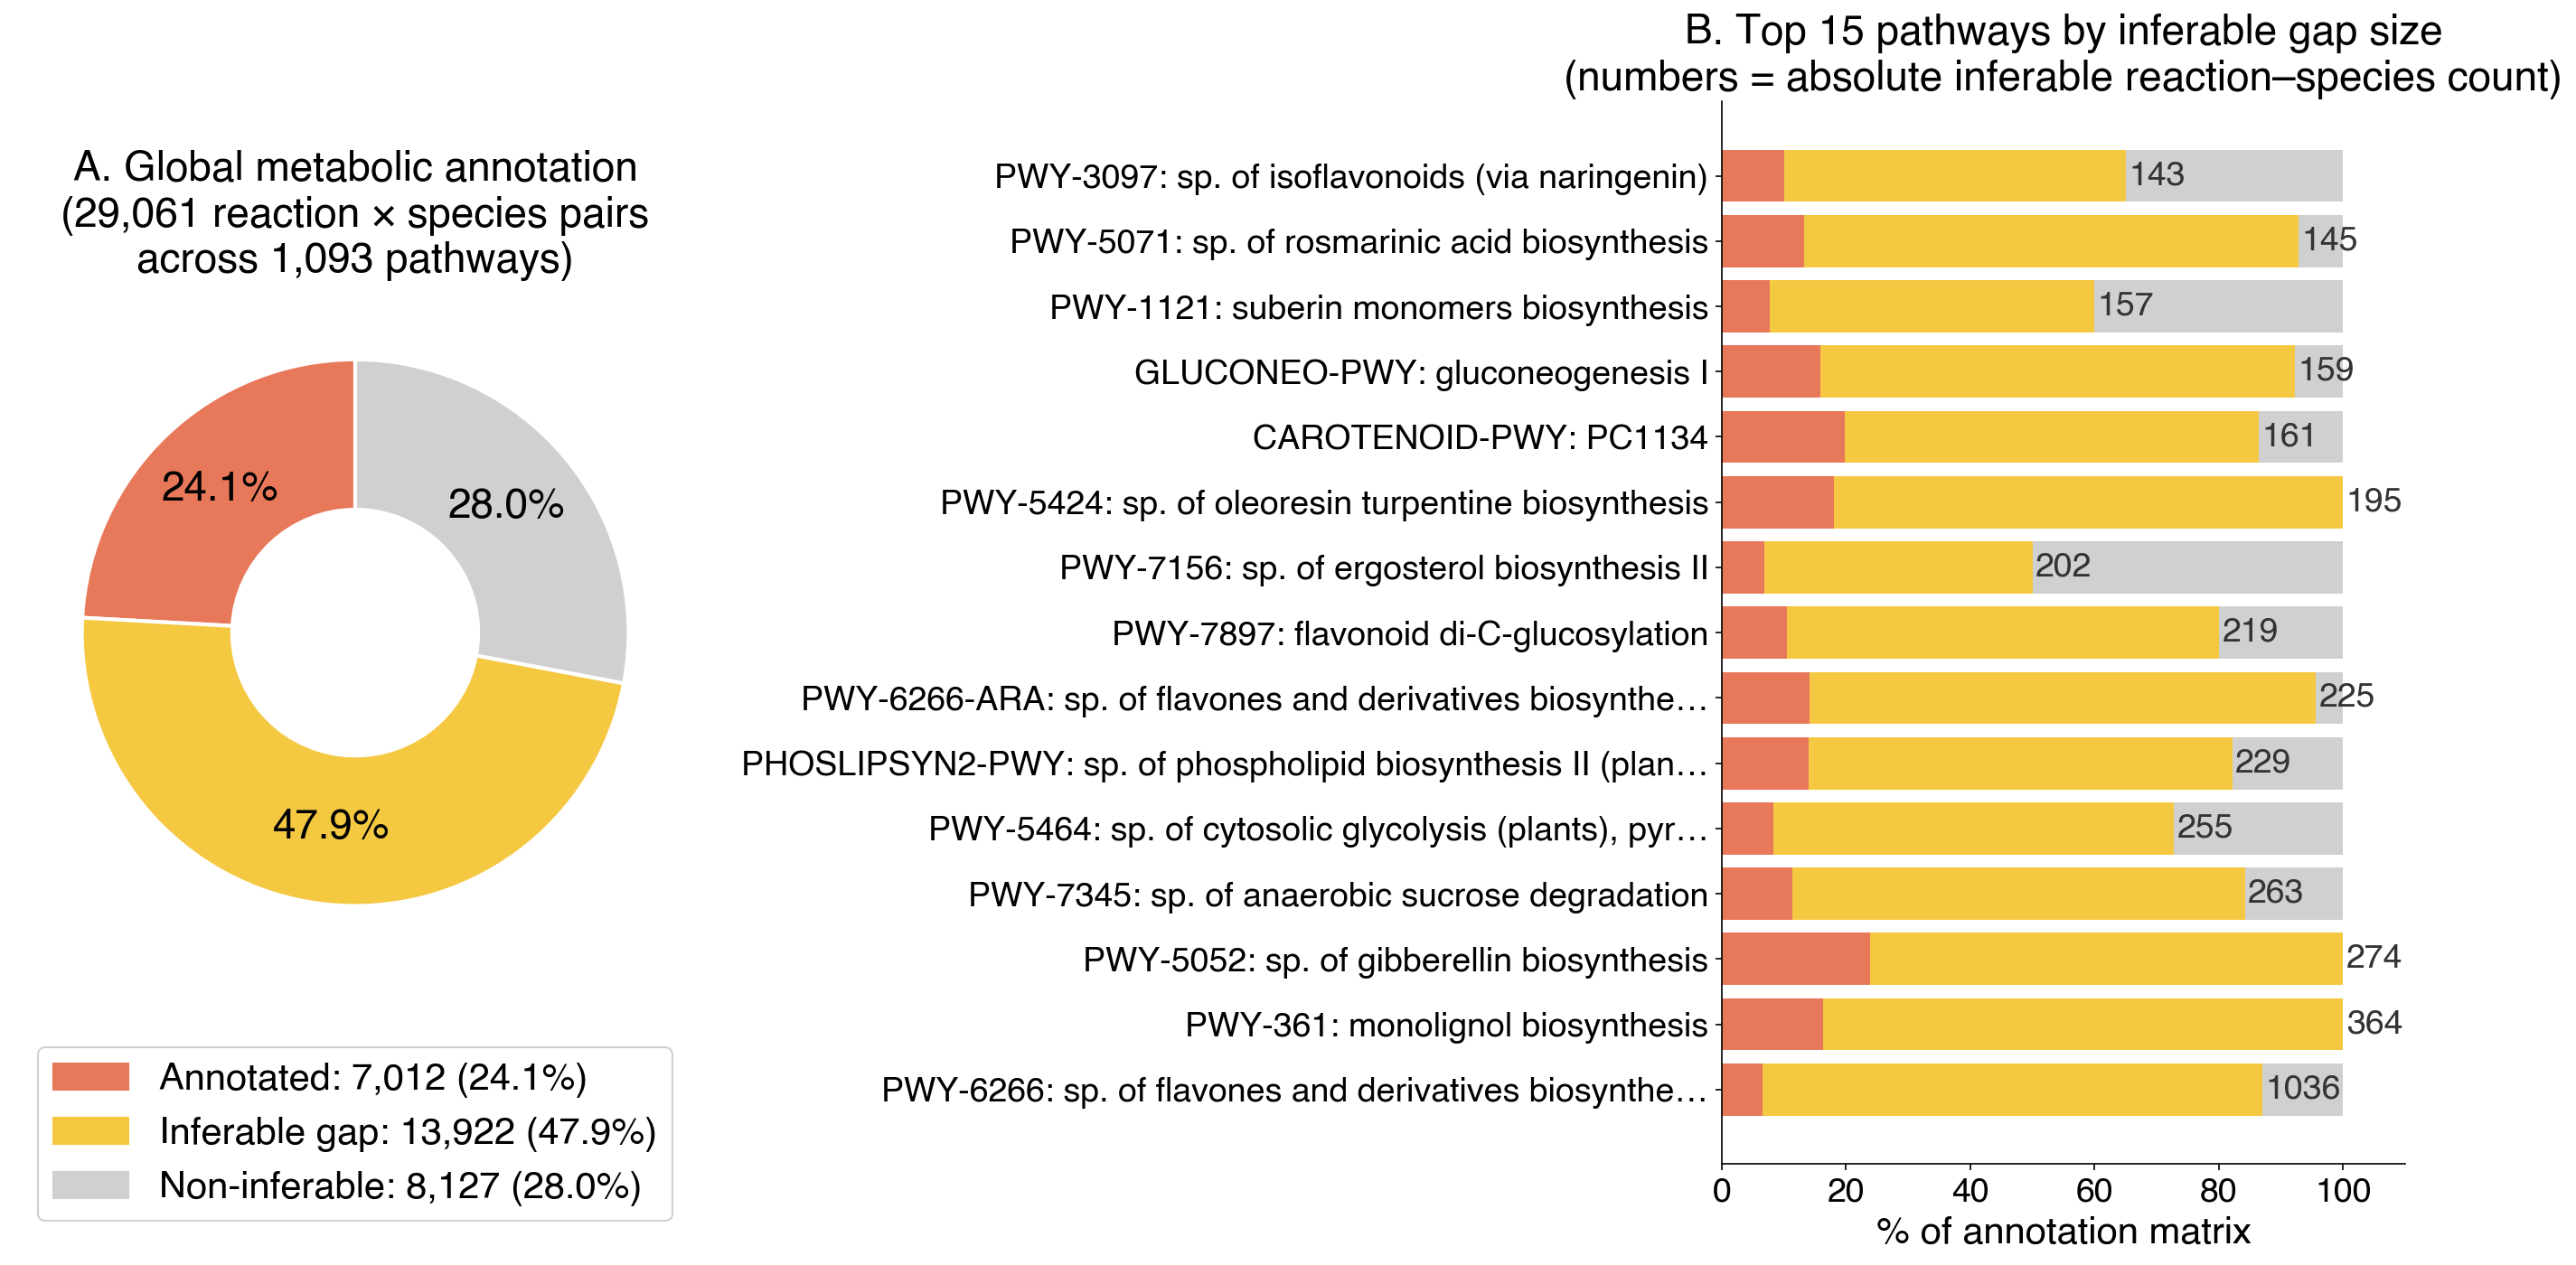

Saved: figures/output/figures/metabolic_space_estimate.svg  +  .pdf

Case study pathway annotation matrix values:
  PWY-5710 (Capsaicin   )  total=  63  annotated= 10 (15.9%)  inferable= 35 (55.6%)
  PWY-7341 (Scopolamine )  total= 208  annotated= 16 ( 7.7%)  inferable=101 (48.6%)
  PWY-7476 (Avenacin A  )  total= 195  annotated= 24 (12.3%)  inferable=111 (56.9%)
  PWY-361 (Monolignol  )  total= 435  annotated= 71 (16.3%)  inferable=364 (83.7%)


In [324]:
import pathlib
import re as _re
import matplotlib.patches as mpatches

# ── Build PC→PWY code mapping ────────────────────────────────────────────────
pwy_code_map = dict(PWY_IDS)
try:
    _pwy_q = (
        "SELECT DISTINCT ?pw_uri ?pwy_code WHERE { GRAPH <%s> {"
        " { ?pw_uri dcterms:identifier ?pwy_code } UNION"
        " { ?pw_uri <http://rdf-plantmetwiki.bioinformatics.nl/vocab/plantcycId> ?pwy_code } }"
        " FILTER(CONTAINS(STR(?pw_uri), '/pathways/PC'))"
        " FILTER(!REGEX(STR(?pwy_code), '^PC[0-9]+$') && STR(?pwy_code) != '')"
        " } LIMIT 2000"
    ) % G_PROPS
    pwy_q = sparql(_pwy_q, timeout=45)
    for _, row in pwy_q.iterrows():
        pc = row.get('pw_uri', '').rstrip('/').split('/')[-1].split('_')[0]
        code = row.get('pwy_code', '')
        if pc and code and not _re.match(r'^PC[0-9]+$', code):
            pwy_code_map.setdefault(pc, code)
except Exception as _e:
    print(f"  [note] pwy_code SPARQL: {_e}")

def pc_to_pwy(pc_id):
    return pwy_code_map.get(pc_id, pc_id)

def shorten_label(s, max_len=42):
    s = s.replace('superpathway of ', 'sp. of ')
    s = s.replace('Superpathway of ', 'Sp. of ')
    s = s.replace(' superpathway', ' sp.')
    s = s.replace(' Superpathway', ' Sp.')
    if len(s) > max_len:
        s = s[:max_len - 1] + '…'
    return s

# ── Figure layout ─────────────────────────────────────────────────────────────
# wspace=0 here — we control spacing via subplots_adjust at the end
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(18, 11),
    gridspec_kw={'width_ratios': [2, 2]},
)

C_ANN  = '#e8785a'
C_INF  = '#f5c842'
C_DARK = '#d0d0d0'
sizes  = [G_ANN, G_INF, G_DARK]
colors = [C_ANN, C_INF, C_DARK]

# ---- Panel A: Donut ─────────────────────────────────────────────────────────
# No external labels — all info in the legend below; percentages inside wedges
wedges, _texts, autotexts = ax1.pie(
    sizes,
    labels=None,        # no text ON the pie (avoids extending into panel B)
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.72,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2.0),
)
for at in autotexts:
    at.set_fontsize(22)

# Legend positioned BELOW the pie, inside the 22% bottom margin we'll reserve
handles_pie = [
    mpatches.Patch(color=C_ANN,  label=f'Annotated: {G_ANN:,} ({100*G_ANN/G_TOTAL:.1f}%)'),
    mpatches.Patch(color=C_INF,  label=f'Inferable gap: {G_INF:,} ({100*G_INF/G_TOTAL:.1f}%)'),
    mpatches.Patch(color=C_DARK, label=f'Non-inferable: {G_DARK:,} ({100*G_DARK/G_TOTAL:.1f}%)'),
]
ax1.legend(
    handles=handles_pie,
    loc='upper center',          # anchor = upper-centre of legend box
    bbox_to_anchor=(0.5, -0.08), # 8% below the axes bottom in axes-coords
    fontsize=20,
    ncol=1,
    frameon=True,
    facecolor='white',
    framealpha=0.9,
    edgecolor='#cccccc',
)

ax1.set_title(
    f'A. Global metabolic annotation\n'
    f'({G_TOTAL:,} reaction × species pairs\n'
    f'across {len(pw_stats):,} pathways)',
    fontsize=22, pad=10,
)

# ---- Panel B: Top 15 pathways by inferable gap ──────────────────────────────
top_n = 15
top   = pw_stats.nlargest(top_n, 'inferable').copy()

try:
    title_map = dict(zip(selection_query['pw_id'],
                         selection_query['title'].str[:55]))
except Exception:
    title_map = {}
top['label'] = top['pw_id'].map(title_map).fillna(top['pw_id'])
top['label'] = top['label'].apply(shorten_label)
top['pwy_id'] = top['pw_id'].map(pc_to_pwy)

y   = np.arange(len(top))
tot = top['total'].values.astype(float)

ax2.barh(y, top['annotated']     / tot * 100, color=C_ANN,  label='Annotated')
ax2.barh(y, top['inferable']     / tot * 100,
         left=top['annotated']   / tot * 100, color=C_INF,  label='Inferable gap')
ax2.barh(y, top['non_inferable'] / tot * 100,
         left=(top['annotated']  + top['inferable']) / tot * 100,
         color=C_DARK, label='Non-inferable')

ax2.set_yticks(y)
ax2.set_yticklabels(
    [f"{r['pwy_id']}: {r['label']}" for _, r in top.iterrows()],
    fontsize=18,
)
for i, (_, r) in enumerate(top.iterrows()):
    if r['total'] > 0:
        bar_end = (r['annotated'] + r['inferable']) / r['total'] * 100
        ax2.text(bar_end + 0.5, i, str(int(r['inferable'])),
                 ha='left', va='center', fontsize=18, color='#333333')

ax2.set_xlim(0, 110)
ax2.set_xlabel('% of annotation matrix', fontsize=20)
ax2.set_title(
    f'B. Top {top_n} pathways by inferable gap size\n'
    f'(numbers = absolute inferable reaction–species count)',
    fontsize=22,
)

ax2.spines[['top', 'right']].set_visible(False)
ax2.tick_params(axis='x', labelsize=18)

# ── Layout: tight_layout first, then reserve bottom space for legends ─────────
plt.tight_layout(pad=1.5)
# wspace: fraction of average subplot width as gap between panels
# With width_ratios [1,2.2] and figsize 18in, avg subplot ≈ 7.5in → wspace=0.30 ≈ 2.25in gap
plt.subplots_adjust(bottom=0.20, wspace=1.5, left=0.02, right=1)

pathlib.Path('figures/output/figures').mkdir(parents=True, exist_ok=True)
plt.savefig('figures/output/figures/metabolic_space_estimate.pdf', bbox_inches='tight')
plt.savefig('figures/output/figures/metabolic_space_estimate.svg', bbox_inches='tight')
plt.show()
print("Saved: figures/output/figures/metabolic_space_estimate.svg  +  .pdf")

print()
print("Case study pathway annotation matrix values:")
for pwid, desc in [('PC629', 'Capsaicin'), ('PC953', 'Scopolamine'),
                   ('PC241', 'Avenacin A'), ('PC504', 'Monolignol')]:
    r = pw_stats[pw_stats['pw_id'] == pwid]
    if not r.empty:
        r = r.iloc[0]
        pwy = pc_to_pwy(pwid)
        print(f"  {pwy} ({desc:12s})  total={r['total']:4d}  "
              f"annotated={r['annotated']:3d} ({100*r['annotated']/r['total']:4.1f}%)  "
              f"inferable={r['inferable']:3d} ({100*r['inferable']/r['total']:4.1f}%)")


**Figure: Metabolic annotation matrix and cross-species inference potential of PlantMetWiki.**
**(A)** Global breakdown of all (reaction × species) pairs across all PC* pathways with ≥1 species
annotation. "Annotated" = `wp:Catalysis` link exists for the species–reaction pair; "Inferable gap" =
gap where ≥1 other species in the same pathway has a Catalysis link for the same reaction
(cross-species transfer candidate); "Non-inferable" = reaction completely uncharacterised across all
species in the pathway. Pathway identifiers are shown as stable PlantCyc accession codes (PWY-\*/RXN-\*).
**(B)** Top 15 pathways ranked by absolute inferable gap size (reaction–species pairs addressable by
cross-species transfer), with colour breakdown showing the proportion of each category.
"Sp." = superpathway. Numbers to the right of each bar show the absolute inferable gap count.

**Strategy for functional annotation prioritization using PlantMetWiki:**

The cross-species inference workflow operates in three ranked steps:

1. **Gap identification** — query `graph/gpml-taxonomy-extra` to identify (pathway, species) pairs with
   annotation depth below a threshold relative to the most-complete species in the same pathway. The
   inferable gap metric computed here provides a ranked list of pathways where this step is most productive.

2. **Evidence ranking** — for each gap reaction, retrieve all species covering it via `wp:Catalysis` in
   the same pathway. Rank evidence sources by: (i) phylogenetic proximity (same genus > same family >
   same order), resolvable via the NCBI taxonomy hierarchy in `graph/ncbitaxon`; (ii) number of reactions
   covered by the evidence species (more complete = more reliable source).

3. **Annotation transfer** — propose `wp:Catalysis` and `wp:organism` updates for the target species,
   linking the gap reaction to a candidate enzyme identified by ortholog search (BLASTp against the
   evidence species' annotated enzyme sequence). Updates target `graph/gpml-taxonomy-extra` only,
   preserving the immutable core WikiPathways RDF.


Query C: per-(pathway, reaction, species) Catalysis coverage...
  → 7,012 (pathway, reaction, species) coverage triples

════════════════════════════════════════════════════════════
  ARABIDOPSIS THALIANA'S SHARE OF THE INFERABLE GAP
════════════════════════════════════════════════════════════
  Sole evidence source (A. thaliana only):      2,921  (21.0%)
  One of several evidence sources:              4,153  (29.8%)
  No A. thaliana evidence (other species only): 6,848  (49.2%)
  → A. thaliana contributes evidence for 50.8% of all inferable gap cells

Top 12 species by potential contribution to the inferable gap:
  Arabidopsis thaliana          7,074
  Lathyrus oleraceus              825
  Zea mays subsp. mays            764
  Solanum lycopersicum            728
  Glycine max                     672
  Oryza sativa Japonica Group     616
  Spinacia oleracea               512
  Catharanthus roseus             504
  Chlamydomonas reinhardtii       495
  Oryza sativa                    46

/var/folders/c8/yjbp_ly50415t5r79fxydc740000gn/T/ipykernel_22005/3120291341.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


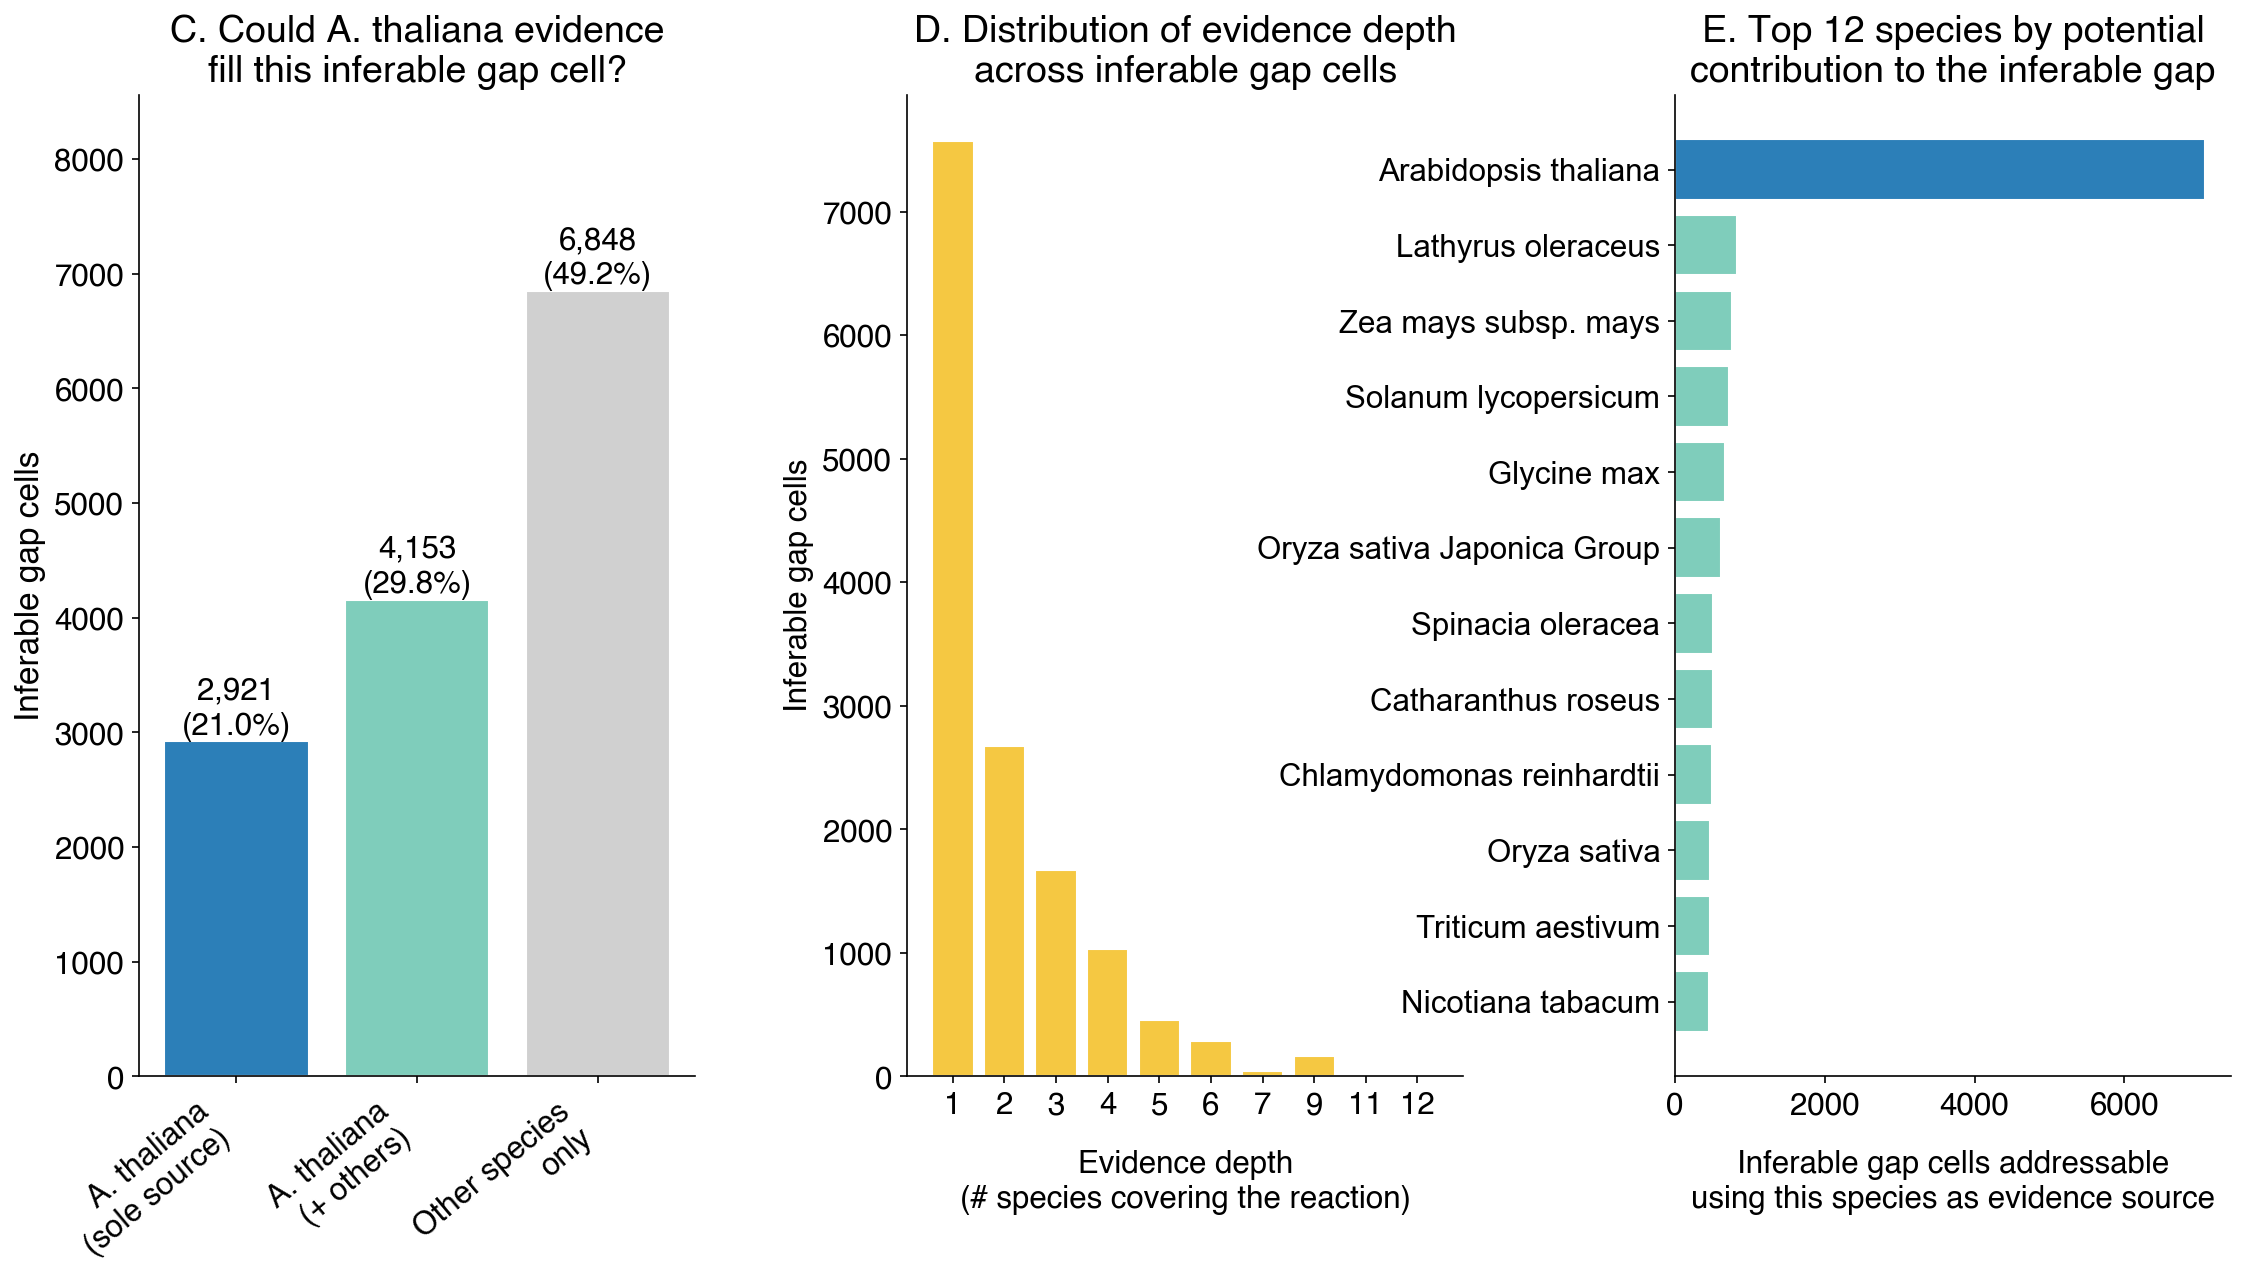


Saved: figures/output/figures/inferable_gap_species_contribution.svg  +  .pdf


In [320]:
# ── Species-level breakdown of the inferable gap ────────────────────────────
# For every inferable (pathway, reaction) gap, which species could provide the
# cross-species evidence? Two questions:
#   1. How much of the 13,922-cell inferable gap could be filled using
#      Arabidopsis thaliana annotations vs. other species only?
#   2. What is the distribution of "evidence depth" (number of species that
#      already cover a given reaction) across the inferable gap cells, and
#      which species contribute the most potential evidence overall?

AT_TAXON = 'http://purl.obolibrary.org/obo/NCBITaxon_3702'  # Arabidopsis thaliana

# Query C: per-(pathway, reaction, species) Catalysis coverage — one row per
# species that provides wp:Catalysis evidence for a given reaction in a pathway
print("Query C: per-(pathway, reaction, species) Catalysis coverage...", flush=True)
rxn_cov_sp = sparql(f"""
SELECT DISTINCT ?pw ?rxn ?taxon
WHERE {{
  GRAPH <{G_PW}> {{
    ?pw a wp:Pathway . FILTER(CONTAINS(STR(?pw), '/PC'))
    ?rxn a wp:Conversion ; dcterms:isPartOf ?pw .
    FILTER(!REGEX(STR(?rxn), "{RXN_ANCHOR_RE}"))
    ?enz dcterms:isPartOf ?pw .
    ?cat a wp:Catalysis ; wp:source ?enz ; wp:target ?rxn .
  }}
  GRAPH <{G_TAX}> {{ ?enz wp:organism ?taxon . FILTER(?taxon != ncbi:33090) }}
}}
""", timeout=300)
print(f"  → {len(rxn_cov_sp):,} (pathway, reaction, species) coverage triples", flush=True)

# Collapse to one row per (pathway, reaction): evidence depth + whether A. thaliana is a source
cov_grouped = rxn_cov_sp.groupby(['pw', 'rxn']).agg(
    n_covering=('taxon', 'nunique'),
    has_AT=('taxon', lambda s: AT_TAXON in set(s)),
).reset_index()
cov_grouped['pw_n_sp']   = cov_grouped['pw'].map(pw_nsp_map)
cov_grouped['inferable'] = (cov_grouped['pw_n_sp'] - cov_grouped['n_covering']).clip(lower=0)

assert int(cov_grouped['inferable'].sum()) == G_INF

AT_only  = int(cov_grouped[cov_grouped['has_AT']  & (cov_grouped['n_covering'] == 1)]['inferable'].sum())
AT_multi = int(cov_grouped[cov_grouped['has_AT']  & (cov_grouped['n_covering'] >  1)]['inferable'].sum())
no_AT    = int(cov_grouped[~cov_grouped['has_AT']]['inferable'].sum())

print()
print("═" * 60)
print("  ARABIDOPSIS THALIANA'S SHARE OF THE INFERABLE GAP")
print("═" * 60)
print(f"  Sole evidence source (A. thaliana only):     {AT_only:>6,}  ({100*AT_only/G_INF:.1f}%)")
print(f"  One of several evidence sources:             {AT_multi:>6,}  ({100*AT_multi/G_INF:.1f}%)")
print(f"  No A. thaliana evidence (other species only):{no_AT:>6,}  ({100*no_AT/G_INF:.1f}%)")
print(f"  → A. thaliana contributes evidence for {100*(AT_only+AT_multi)/G_INF:.1f}% "
      f"of all inferable gap cells")

# Distribution of "evidence depth" (number of species covering a reaction)
# across inferable gap cells
depth_dist = (cov_grouped[cov_grouped['inferable'] > 0]
               .groupby('n_covering')['inferable'].sum())

# Top contributing species: for each species, total inferable gap cells in
# pathways/reactions where that species provides Catalysis evidence
rxn_cov_sp = rxn_cov_sp.merge(cov_grouped[['pw', 'rxn', 'inferable']], on=['pw', 'rxn'])
sp_contrib = rxn_cov_sp.groupby('taxon')['inferable'].sum().sort_values(ascending=False)

top_n = 12
top_taxa = sp_contrib.head(top_n).index.tolist()
values_str = " ".join(f"<{t}>" for t in top_taxa)
sp_labels = sparql(f"""
SELECT ?taxon ?label WHERE {{
  GRAPH <{G_NCBI}> {{ ?taxon rdfs:label ?label }}
  VALUES ?taxon {{ {values_str} }}
}}""")
label_map = dict(zip(sp_labels['taxon'], sp_labels['label']))

print()
print(f"Top {top_n} species by potential contribution to the inferable gap:")
for taxon, n in sp_contrib.head(top_n).items():
    print(f"  {label_map.get(taxon, taxon):28s}  {n:5,}")

# ── Figure: 3 panels ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 8.5), gridspec_kw={'wspace': 0.38})

# Panel A: A. thaliana's share of the inferable gap
ax = axes[0]
cats   = ['A. thaliana\n(sole source)', 'A. thaliana\n(+ others)', 'Other species\nonly']
vals   = [AT_only, AT_multi, no_AT]
colors_a = ['#2c7fb8', '#7fcdbb', '#d0d0d0']
bars = ax.bar(cats, vals, color=colors_a, edgecolor='white')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:,}\n({100*v/G_INF:.1f}%)",
            ha='center', va='bottom', fontsize=15, fontname='Helvetica')
ax.set_ylabel('Inferable gap cells', fontsize=16, fontname='Helvetica')
ax.set_title('C. Could A. thaliana evidence\nfill this inferable gap cell?',
              fontsize=18, fontname='Helvetica')
ax.set_ylim(0, max(vals) * 1.25)
plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=15)
ax.tick_params(axis='x', which='both', labelsize=15, pad=6)
ax.spines[['top', 'right']].set_visible(False)

# Panel B: distribution of evidence depth across inferable gap cells
ax = axes[1]
ax.bar(depth_dist.index.astype(str), depth_dist.values, color='#f5c842', edgecolor='white')
ax.set_xlabel('Evidence depth\n(# species covering the reaction)', fontsize=15, fontname='Helvetica', labelpad=14)
ax.set_ylabel('Inferable gap cells', fontsize=15, fontname='Helvetica')
ax.set_title('D. Distribution of evidence depth\nacross inferable gap cells',
              fontsize=18, fontname='Helvetica')
ax.tick_params(axis='both', which='both', labelsize=15)
ax.spines[['top', 'right']].set_visible(False)

# Panel C: top species by potential contribution
ax = axes[2]
top_sp = sp_contrib.head(top_n).iloc[::-1]
labels_plot = [label_map.get(t, t) for t in top_sp.index]
colors_c = ['#2c7fb8' if t == AT_TAXON else '#7fcdbb' for t in top_sp.index]
ax.barh(labels_plot, top_sp.values, color=colors_c, edgecolor='white')
ax.set_xlabel('Inferable gap cells addressable\nusing this species as evidence source',
               fontsize=15, fontname='Helvetica', labelpad=14)
ax.set_title(f'E. Top {top_n} species by potential\ncontribution to the inferable gap',
              fontsize=18, fontname='Helvetica')
ax.tick_params(axis='x', which='both', labelsize=15)
ax.spines[['top', 'right']].set_visible(False)
for tick_label in ax.get_yticklabels():
    tick_label.set_fontsize(15)
    tick_label.set_fontname('Arial')

plt.tight_layout()
pathlib.Path('figures/output/figures').mkdir(parents=True, exist_ok=True)
plt.savefig('figures/output/figures/inferable_gap_species_contribution.pdf', bbox_inches='tight')
plt.savefig('figures/output/figures/inferable_gap_species_contribution.svg', bbox_inches='tight')
plt.show()
print()
print("Saved: figures/output/figures/inferable_gap_species_contribution.svg  +  .pdf")


### Panels C–E: species-level breakdown of the inferable gap

Of the **13,922 inferable gap cells** (cells where a (pathway, reaction, species)
combination lacks direct `wp:Catalysis` annotation but ≥1 other species in the same
pathway covers that reaction):

- **2,921 cells (21.0%)** could *only* be filled using *Arabidopsis thaliana*
  evidence — A. thaliana is the sole annotated species for that reaction.
- **4,153 cells (29.8%)** have A. thaliana as one of several possible evidence sources.
- **6,848 cells (49.2%)** have no A. thaliana evidence at all — inference for these
  cells must come from other species (e.g. *Glycine max*, *Solanum lycopersicum*,
  *Zea mays*, *Oryza sativa*, *Nicotiana tabacum*, *Triticum aestivum*, ...).

Overall, **A. thaliana annotations could contribute evidence to ~51% of all
inferable gap cells** (Panel C) — reflecting its outsized annotation depth in
PlantCyc/PlantMetWiki — but roughly **half of the inferable gap is independent of
A. thaliana** and relies entirely on evidence from other annotated species.

**Evidence depth (Panel D):** the majority of inferable gap cells (7,568 / 54.4%)
have only **one** potential source species — cross-species transfer for these cells
depends on a single annotated species being correct, with no corroborating evidence.
The remaining 6,354 cells (45.6%) have ≥2 independent species covering the same
reaction, providing mutually corroborating evidence for the proposed annotation.

**Top contributing species (Panel E):** *Arabidopsis thaliana* (7,074 cells) is by
far the largest single source of potential cross-species evidence — roughly an
order of magnitude larger than the next species, *Lathyrus oleraceus* (825),
*Zea mays* (764), *Solanum lycopersicum* (728), and *Glycine max* (672). This
reflects the PlantCyc/PlantMetWiki annotation-depth hierarchy: a small number of
heavily curated model/crop species, with *Arabidopsis* chief among them, underpin
most of the cross-species inference potential captured in this matrix.